# Feature Space Creation

This notebook builds the **modelling-ready feature matrix** from MIMIC-IV extracts for predicting causative organism therapy groups and empirical antibiotic appropriateness in ICU patients with respiratory infections.

### Key design decisions

1. **First ICU stay** enforced on `resp_admission_df` after load — one row per `hadm_id`.
2. **Temporal window**: vitals, labs, and antibiotic exposure are restricted from **hospital admission** through **`first_ast_time` + 24 h** (the empirical decision period, before AST results are typically reported at 48–72 h).
3. **Target filtering** uses `resp_index_ast_df` (the index-culture cohort matching `time_df`, 3,882 `hadm_id`s) — NOT the broader `resp_ast_df` (4,426 `hadm_id`s) — to ensure targets are created only for patients in the final modelling set.
4. **LLM results** are used purely for preprocessing/standardisation (organism classification → `final_class`; appropriateness labelling → `mapped_letter`). They are **not** model features.
5. **Binary task**: `feature_df_binary_modeling` drops culture/LLM audit columns (`AST_PATTERN`, `final_class`, `org_name`, `storetime`) to prevent data leakage.

---

### How to run

- Run **top to bottom** the first time; afterwards you can reload intermediate `.parquet` files where marked.
- After editing helper functions, re-run the **Functions** section, then downstream cells that depend on them.
- **Outputs:**
  - Organism (multilabel) task → `feature_df_plus` / `feature_df_target`
  - Binary (appropriateness) task → `feature_df_binary_target` (full) + `feature_df_binary_modeling` (training-safe)


## Notebook map

| Section | Purpose |
|--------|---------|
| Setup | Imports, paths, options |
| Functions | `get_prior_events`, `extract_first_icu_stay`, … |
| Loading | MIMIC extracts (admits, cohort, micro, AST, labs, meds) |
| Prior features | Prior AST flags, prior AB count, Charlson |
| Feature space | Time windows, vitals/lab aggregations |
| Targets | LLM labels, organism groups, binary mapping |
| Merge | `feature_df_target` (multilabel) & `feature_df_binary_*` (binary) |


## Setup

Imports and display options. `tools.helpers` (`hh`) and `tools.filter_helpers` (`fh`) are used throughout.


In [1]:
# Core imports: pandas + project helpers (`hh`, `fh`). Venn imports are optional for exploratory plots.

import multilabel_model as mm
from sklearn.pipeline import Pipeline
import pandas as pd
from sqlalchemy import create_engine
import tools.helpers as hh
import tools.filter_helpers as fh
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
from venn import venn
from pathlib import Path

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
# Re-run this cell after editing `multilabel_model.py` or `tools/filter_helpers.py`.
import importlib
importlib.reload(mm)
importlib.reload(fh)


<module 'tools.filter_helpers' from '/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building/tools/filter_helpers.py'>

In [4]:
pd.set_option('display.max_columns', None)


In [5]:
DATA_ROOT = Path("/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building")
PARQ_DIR = DATA_ROOT / "parq"

### Paths

`DATA_ROOT` / `PARQ_DIR` point to this project and its `parq/` cache. Update if you move the repo.


## Functions

Reusable helpers used later in this notebook:

- **`get_prior_events`** — Restricts events to **strictly before** the index admission start time for the same `subject_id` (prior admissions only; avoids same-admission leakage).
- **`extract_first_icu_stay`** — One row per `hadm_id`: earliest ICU `intime` / `icu_admit_time`.
- **`get_prior_events_forloop`** — Row-wise prior-event expansion (heavier; use when vectorised merge is awkward).


In [6]:
def get_prior_events(anchor_df, event_df,
                     subject_col='subject_id',
                     hadm_col='hadm_id',
                    event_time_col='storetime',
                    anchor_time_col='hospital_admit_time'):
    """
    For each admission in anchor_df, find prior admissions
    of the same subject in event_df and attach anchor info.
    """

    anchor = anchor_df.copy()
    events = event_df.copy()

    # Ensure datetime
    anchor[anchor_time_col] = pd.to_datetime(anchor[anchor_time_col])
    events[event_time_col] = pd.to_datetime(events[event_time_col])

    # Rename anchor columns
    anchor = anchor.rename(columns={
        hadm_col: 'anchor_hadm_id',
        anchor_time_col: 'anchor_hadm_time'
    })

    # Rename event hadm_id to prior_hadm_id
    events = events.rename(columns={
        hadm_col: 'prior_hadm_id'
    })

    # Merge on subject
    merged = events.merge(
        anchor[[subject_col, 'anchor_hadm_id', 'anchor_hadm_time']],
        on=subject_col,
        how='inner'
    )

    # Keep only admissions before anchor admission
    prior = merged[merged[event_time_col] < merged['anchor_hadm_time']]

    return prior.reset_index(drop=True)

In [7]:
def extract_first_icu_stay(df,
                           hadm_col="hadm_id",
                           stay_col="stay_id",
                           hadm_time_col="hadm_time",
                           intime_col="intime"):
    """
    Extract first ICU stay per hadm_id.
    Final output sorted by hadm_time (chronological admission order).
    """

    df = df.copy()

    # Ensure datetime for hadm_time
    if hadm_time_col in df.columns:
        df[hadm_time_col] = pd.to_datetime(df[hadm_time_col])

    # Case 1: stay_id exists → choose first ICU stay per hadm
    if stay_col in df.columns:

        # Sort within each hadm by ICU intime if available
        if intime_col in df.columns:
            df[intime_col] = pd.to_datetime(df[intime_col])
            df = df.sort_values(by=[hadm_col, intime_col])
        else:
            df = df.sort_values(by=[hadm_col, stay_col])

        first_df = df.groupby(hadm_col, as_index=False).first()

    # Case 2: no stay_id → keep unique hadm
    else:
        first_df = df.drop_duplicates(subset=[hadm_col])

    # Final sorting by hadm_time
    if hadm_time_col in first_df.columns:
        first_df = first_df.sort_values(by=hadm_time_col)

    return first_df.reset_index(drop=True)

In [8]:


def get_prior_events_forloop(anchor_df,
                             event_df,
                             subject_col="subject_id",
                             hadm_col="hadm_id",
                             anchor_time_col="hadm_time",
                             event_time_col="hadm_time"):
    """
    Returns all events that occurred prior to each anchor admission.

    Output:
    - All columns from event_df (prior events)
    - Plus anchor_hadm_id and anchor_hadm_time
    """

    anchor_df = anchor_df.copy()
    event_df = event_df.copy()

    # Ensure datetime
    anchor_df[anchor_time_col] = pd.to_datetime(anchor_df[anchor_time_col])
    event_df[event_time_col] = pd.to_datetime(event_df[event_time_col])

    results = []

    for _, anchor_row in anchor_df.iterrows():

        subject_id = anchor_row[subject_col]
        anchor_hadm_id = anchor_row[hadm_col]
        anchor_time = anchor_row[anchor_time_col]

        # Filter events for same subject
        patient_events = event_df[
            event_df[subject_col] == subject_id
        ]

        # Keep only events prior to anchor time
        prior_events = patient_events[patient_events[event_time_col] < anchor_time]

        for _, event_row in prior_events.iterrows():

            row_dict = event_row.to_dict()

            # Add anchor info
            row_dict["anchor_hadm_id"] = anchor_hadm_id
            row_dict["anchor_hadm_time"] = anchor_time

            results.append(row_dict)

    final_df = pd.DataFrame(results)

    # Sort output chronologically
    if not final_df.empty:
        final_df = final_df.sort_values(
            by=[subject_col, "anchor_hadm_time", event_time_col]
        ).reset_index(drop=True)

    return final_df

## Loading Datasets


### Main datasets


Hospital- and ICU-level admissions table from MIMIC preprocessing. Used for merges and prior-event logic.


#### All Admission dataframe

All hospital admissions in MIMIC-IV (62,657 rows). Used as a lookup table for `hadm_id ↔ stay_id` mapping and as the event source for prior-history computations.


In [9]:
all_adm_df= hh.load_data('./parq/all_adm_df_27Feb26_1738.parquet')
hh.dxx(all_adm_df)

11.9k Unique Patient IDs (11905)
59.0k Unique Admission IDs (59024)
24.5k Unique ICU Stay IDs (24504)
62.7k Rows, shape: (62657, 16)



,subject_id,gender,anchor_age,anchor_year,hadm_id,hospital_admit_time,hospital_discharge_time,hospital_death_time,stay_id,icu_admit_time,icu_discharge_time,icu_los_days,admission_type,admission_location,discharge_location,race
dtype,int64,object,int64,int64,int64,datetime64[ns],datetime64[ns],datetime64[ns],float64,datetime64[ns],datetime64[ns],float64,object,object,object,object
NotNA | NA,62657 | 0,62657 | 0,62657 | 0,62657 | 0,62657 | 0,62657 | 0,62657 | 0,4304 | 58353,24504 | 38153,24504 | 38153,24495 | 38162,24495 | 38162,62657 | 0,62657 | 0,53655 | 9002,62657 | 0
nunique,11905,2,73,96,59024,58945,58790,3424,24505,24504,24496,24019,9,11,14,33
0,10006508,F,71,2132,20850343,2132-03-28 22:38:00,2132-04-02 15:00:00,NaT,nan,NaT,NaT,nan,OBSERVATION ADMIT,EMERGENCY ROOM,HOME HEALTH CARE,BLACK/AFRICAN AMERICAN
1,10001843,M,73,2131,21728396,2131-11-09 16:05:00,2131-11-11 11:23:00,NaT,nan,NaT,NaT,nan,OBSERVATION ADMIT,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,WHITE
2,10001843,M,73,2131,26133978,2134-12-05 00:10:00,2134-12-06 12:54:00,2134-12-06 12:54:00,39698942.000000,2134-12-05 18:50:03,2134-12-06 14:38:26,0.825266,URGENT,TRANSFER FROM HOSPITAL,DIED,WHITE


In [10]:
first_adm_df= extract_first_icu_stay(df= all_adm_df, intime_col='icu_admit_time',hadm_time_col='hospital_admit_time')

### Respiratory ICU cohort

#### Source parquet

Load `resp_inf_cohort_*.parquet` (ICD-defined respiratory infection cohort from upstream notebooks).

#### First ICU stay per admission

The following cell restricts to **one row per `hadm_id`**: the ICU stay with the earliest `icu_admit_time` (or `intime` if that column is used). This matches the thesis requirement that only the first ICU stay is analysed.


In [11]:
resp_admission_df = pd.read_parquet(PARQ_DIR / "resp_inf_cohort_23Jan26_1953.parquet")
hh.dxx(resp_admission_df)

11.9k Unique Patient IDs (11905)
13.6k Unique Admission IDs (13611)
16.4k Unique ICU Stay IDs (16438)
18.1k Rows, shape: (18109, 19)



,subject_id,gender,anchor_age,anchor_year,hadm_id,hospital_admit_time,hospital_discharge_time,hospital_death_time,stay_id,icu_admit_time,icu_discharge_time,icu_los_days,admission_type,admission_location,discharge_location,race,seq_num,icd_version,icd_code
dtype,int64,object,int64,int64,int64,datetime64[ns],datetime64[ns],datetime64[ns],int64,datetime64[ns],datetime64[ns],float64,object,object,object,object,int64,int64,object
NotNA | NA,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0,4055 | 14054,18109 | 0,18109 | 0,18099 | 10,18099 | 10,18109 | 0,18109 | 0,18074 | 35,18109 | 0,18109 | 0,18109 | 0,18109 | 0
nunique,11905,2,73,96,13611,13607,13598,2831,16438,16438,16430,16246,9,11,14,33,38,2,142
0,10003637,M,57,2145,28317408,2150-05-14 19:51:00,2150-05-22 16:25:00,2150-05-22 16:25:00,32824762,2150-05-16 07:30:28,2150-05-22 18:38:55,6.464201,EW EMER.,WALK-IN/SELF REFERRAL,DIED,PORTUGUESE,3,10,J1289
1,10010888,M,43,2174,20162667,2174-01-09 22:19:00,2174-01-27 16:00:00,NaT,33318955,2174-01-09 00:21:00,2174-01-18 00:48:41,9.019225,EW EMER.,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,WHITE,2,10,J1282
2,10011938,F,57,2121,23798746,2133-08-13 09:48:00,2133-10-05 19:27:00,NaT,31780787,2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,EW EMER.,TRANSFER FROM SKILLED NURSING FACILITY,REHAB,WHITE - OTHER EUROPEAN,2,10,J15212


In [12]:
# Thesis / methods: one ICU stay per hospital admission (earliest ICU intime per hadm_id).

resp_admission_df = extract_first_icu_stay(
    resp_admission_df,
    hadm_col="hadm_id",
    stay_col="stay_id",
    hadm_time_col="hospital_admit_time",
    intime_col="icu_admit_time",
)
hh.dxx(resp_admission_df)

11.9k Unique Patient IDs (11905)
13.6k Unique Admission IDs (13611)
13.6k Unique ICU Stay IDs (13611)
13.6k Rows, shape: (13611, 19)



,hadm_id,subject_id,gender,anchor_age,anchor_year,hospital_admit_time,hospital_discharge_time,hospital_death_time,stay_id,icu_admit_time,icu_discharge_time,icu_los_days,admission_type,admission_location,discharge_location,race,seq_num,icd_version,icd_code
dtype,int64,int64,object,int64,int64,datetime64[ns],datetime64[ns],datetime64[ns],int64,datetime64[ns],datetime64[ns],float64,object,object,object,object,int64,int64,object
NotNA | NA,13611 | 0,13611 | 0,13611 | 0,13611 | 0,13611 | 0,13611 | 0,13611 | 0,2830 | 10781,13611 | 0,13611 | 0,13602 | 9,13602 | 9,13611 | 0,13611 | 0,13579 | 32,13611 | 0,13611 | 0,13611 | 0,13611 | 0
nunique,13611,11905,2,73,96,13607,13598,2831,13611,13611,13603,13468,9,11,14,33,37,2,136
0,20446666,12770182,M,53,2110,2110-01-18 17:46:00,2110-01-21 16:30:00,NaT,34901199,2110-01-18 17:47:47,2110-01-20 22:25:09,2.192616,EW EMER.,TRANSFER FROM HOSPITAL,HOME,WHITE,2,10,J189
1,29477062,10116419,M,56,2110,2110-01-22 05:56:00,2110-02-12 14:40:00,NaT,36274299,2110-01-22 05:56:38,2110-02-06 20:39:10,15.612870,EW EMER.,INFORMATION NOT AVAILABLE,SKILLED NURSING FACILITY,UNKNOWN,4,10,J189
2,25370746,17599014,M,70,2110,2110-01-30 22:08:00,2110-02-26 15:58:00,NaT,33321267,2110-02-05 12:27:01,2110-02-10 22:43:13,5.427917,OBSERVATION ADMIT,AMBULATORY SURGERY TRANSFER,SKILLED NURSING FACILITY,UNKNOWN,4,10,J1289


#### Respiratory diagnosis Dataframe


In [13]:
diagnosis_df = pd.read_parquet(PARQ_DIR / "df_resp_inf_icu_final.parq")
hh.dxx(diagnosis_df)

11.9k Unique Patient IDs (11905)
13.6k Unique Admission IDs (13611)
16.4k Unique ICU Stay IDs (16438)
18.1k Rows, shape: (18109, 6)



,subject_id,hadm_id,stay_id,seq_num,icd_version,icd_code
dtype,int64,int64,int64,int64,int64,object
NotNA | NA,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0
nunique,11905,13611,16438,38,2,142
0,10001843,26133978,39698942,4,10,J189
1,10001884,26184834,37510196,19,10,J0190
2,10002155,20345487,32358465,2,9,486


### Feature Datasets


#### Demographics

Patient demographics per ICU stay: gender, age at admission, insurance, race, marital status, language, admission type/location.


In [14]:
demographics_df= hh.load_data('./parq/demo_df_26Feb26_1629.parquet')
hh.dxx(demographics_df)


11.9k Unique Patient IDs (11905)
13.6k Unique Admission IDs (13611)
16.4k Unique ICU Stay IDs (16438)
16.4k Rows, shape: (16438, 23)



,subject_id,hadm_id,stay_id,gender,age_at_admission,anchor_age,anchor_year,anchor_year_group,hospital_admit_time,hospital_discharge_time,admission_type,admission_location,discharge_location,insurance,race,marital_status,language,first_careunit,last_careunit,intime,outtime,los,admission_year
dtype,int64,int64,int64,object,int64,int64,int64,object,datetime64[ns],datetime64[ns],object,object,object,object,object,object,object,object,object,datetime64[ns],datetime64[ns],float64,int32
NotNA | NA,16438 | 0,16438 | 0,16438 | 0,16438 | 0,16438 | 0,16438 | 0,16438 | 0,16438 | 0,16438 | 0,16438 | 0,16438 | 0,16438 | 0,16405 | 33,16252 | 186,16438 | 0,14967 | 1471,16360 | 78,16438 | 0,16438 | 0,16438 | 0,16429 | 9,16429 | 9,16438 | 0
nunique,11905,13611,16438,2,85,73,96,5,13607,13598,9,11,14,6,33,5,26,14,14,16438,16430,16246,104
0,10001843,26133978,39698942,M,76,73,2131,2017 - 2019,2134-12-05 00:10:00,2134-12-06 12:54:00,URGENT,TRANSFER FROM HOSPITAL,DIED,Medicare,WHITE,SINGLE,English,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2134-12-05 18:50:03,2134-12-06 14:38:26,0.825266,2134
1,10001884,26184834,37510196,F,77,68,2122,2008 - 2010,2131-01-07 20:39:00,2131-01-20 05:15:00,OBSERVATION ADMIT,EMERGENCY ROOM,DIED,Medicare,BLACK/AFRICAN AMERICAN,MARRIED,English,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2131-01-11 04:20:05,2131-01-20 08:27:30,9.171817,2131
2,10002155,20345487,32358465,F,83,80,2128,2008 - 2010,2131-03-09 20:33:00,2131-03-10 01:55:00,EW EMER.,EMERGENCY ROOM,DIED,Medicare,WHITE,MARRIED,English,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2131-03-09 21:33:00,2131-03-10 18:09:21,0.858576,2131


#### `time_df` — index culture timing

Load the table produced by **`02_03_Feature_space_clean.ipynb`** (`time_df_after_first_icu_*.parquet`). It defines **`first_ast_time`** per `hadm_id` and cohort exclusions (no pre–first-ICU cultures on the index admission).

The next cell picks the **newest** matching parquet under `parq/`. After changing timing rules, re-run the clean 02_03 notebook, then this cell.


In [ ]:
# Newest canonical timing file (prefer clean-notebook output)
_after = sorted(PARQ_DIR.glob("time_df_after_first_icu*.parquet"), key=lambda p: p.stat().st_mtime, reverse=True)
_fallback = sorted(PARQ_DIR.glob("time_df*.parquet"), key=lambda p: p.stat().st_mtime, reverse=True)
_paths = _after if _after else _fallback
if not _paths:
    raise FileNotFoundError("No time_df*.parquet in parq/. Run 02_03_Feature_space_clean.ipynb first.")
time_df = pd.read_parquet(_paths[0])
print("time_df:", _paths[0].name, time_df.shape)
hh.dxx(time_df)

# time_df_after_first_icu12Apr26_1615

time_df: time_df_after_first_icu12Apr26_1615.parquet (3882, 14)
3.6k Unique Patient IDs (3588)
3.9k Unique Admission IDs (3882)
3.3k Unique ICU Stay IDs (3311)
3.9k Rows, shape: (3882, 14)



,subject_id,hadm_id,stay_id,hospital_admit_time,hospital_discharge_time,hospital_death_time,icu_admit_time,icu_discharge_time,first_icu_admit_time,first_ast_time,ast_inside_icu_stay,hours_adm_to_ast,hours_icu_to_ast,hours_first_icu_admit_to_ast
dtype,int64,int64,float64,datetime64[ns],datetime64[ns],datetime64[ns],datetime64[ns],datetime64[ns],datetime64[ns],datetime64[ns],bool,float64,float64,float64
NotNA | NA,3882 | 0,3882 | 0,3311 | 571,3882 | 0,3882 | 0,915 | 2967,3311 | 571,3311 | 571,3882 | 0,3882 | 0,3882 | 0,3882 | 0,3882 | 0,3882 | 0
nunique,3588,3882,3312,3880,3880,916,3312,3312,3882,3882,2,3264,3655,3657
0,18172155,20009330,36841282.000000,2144-01-01 00:33:00,2144-01-09 21:07:00,NaT,2144-01-01 04:26:36,2144-01-06 22:46:18,2144-01-01 04:26:36,2144-01-01 11:53:00,True,11.333333,7.440000,7.440000
1,19318312,20013496,32840324.000000,2161-11-04 04:33:00,2161-12-01 17:15:00,NaT,2161-11-04 06:58:00,2161-11-22 18:27:35,2161-11-04 06:58:00,2161-11-04 22:30:00,True,17.950000,15.533333,15.533333
2,17333498,20015712,nan,2162-05-14 03:54:00,2162-06-11 13:55:00,NaT,NaT,NaT,2162-05-14 04:28:00,2162-05-22 16:00:00,False,204.100000,203.533333,203.533333


<Axes: >

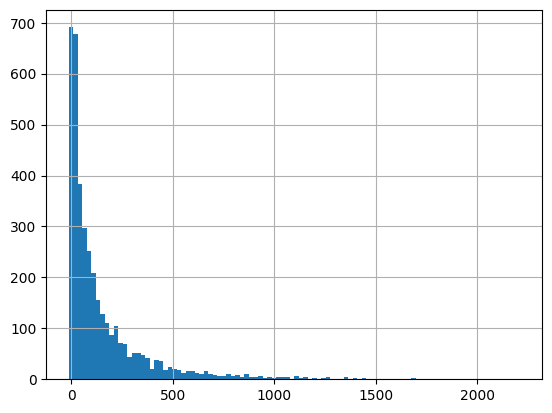

In [16]:
time_df.hours_adm_to_ast.hist(bins=100)

<Axes: >

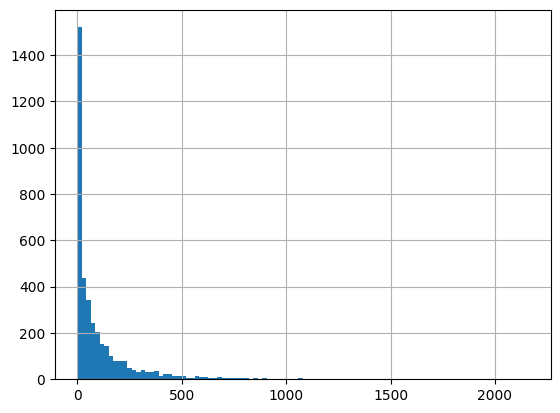

In [17]:
time_df.hours_icu_to_ast.hist(bins=100)


#### Vitals


In [18]:
vitals_df=hh.load_data('./parq/vitals_df29Mar26_2344.parquet')
hh.dxx(vitals_df)



11.9k Unique Patient IDs (11905)
13.6k Unique Admission IDs (13611)
16.4k Unique ICU Stay IDs (16437)
17.2M Rows, shape: (17209316, 9)



,subject_id,hadm_id,stay_id,intime,outtime,itemid,charttime,valuenum,d_vital_name
dtype,int64,int64,int64,datetime64[ns],datetime64[ns],int64,datetime64[ns],float64,object
NotNA | NA,17209316 | 0,17209316 | 0,17209316 | 0,17209316 | 0,17190513 | 18803,17209316 | 0,17209316 | 0,17209316 | 0,17209316 | 0
nunique,11905,13611,16437,16437,16429,18,2163846,1423,8
0,10008924,23676183,30244392,2139-07-09 23:42:19,2139-07-11 17:04:07,220045,2139-07-09 23:42:00,97.000000,heart_rate
1,10001843,26133978,39698942,2134-12-05 18:50:03,2134-12-06 14:38:26,220045,2134-12-06 07:00:00,129.000000,heart_rate
2,10001843,26133978,39698942,2134-12-05 18:50:03,2134-12-06 14:38:26,220210,2134-12-06 07:00:00,18.000000,respiratory_rate


#### All Microbiology Records - including non respiratory admissions


In [19]:
all_micro_df= hh.load_data('./parq/all_micro_df_26Feb26_0625.parquet')
hh.dxx(all_micro_df)

11.5k Unique Patient IDs (11462)
18.9k Unique Admission IDs (18878)
22.4k Unique ICU Stay IDs (22440)
519.5k Rows, shape: (519525, 19)



,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,microevent_id,chartdate,charttime,spec_type_desc,storetime,test_name,org_name,ab_name,interpretation,dilution_value,comments
dtype,int64,int64,int64,object,object,datetime64[ns],datetime64[ns],float64,int64,datetime64[ns],datetime64[ns],object,datetime64[ns],object,object,object,object,float64,object
NotNA | NA,519525 | 0,519525 | 0,519525 | 0,519525 | 0,519525 | 0,519525 | 0,519525 | 0,519525 | 0,519525 | 0,519525 | 0,519525 | 0,519525 | 0,514796 | 4729,519525 | 0,195856 | 323669,160393 | 359132,160393 | 359132,152509 | 367016,429900 | 89625
nunique,11462,18878,22440,14,14,22439,22440,22073,364102,30702,154248,75,225294,131,332,48,7,26,265
0,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812,2602,2135-01-04 00:00:00,2135-01-04 13:41:00,PLEURAL FLUID,2135-01-04 19:19:00,GRAM STAIN,None,None,None,nan,NO POLYMORPHONUCLEAR LEUKOCYTES SEEN. NO MICROORGANISMS SEEN.
1,10005817,20626031,32604416,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2132-12-15 09:29:01,2132-12-17 18:06:07,2.359097,2591,2132-12-12 00:00:00,2132-12-12 02:08:00,URINE,2132-12-17 14:25:00,URINE CULTURE,"STAPHYLOCOCCUS, COAGULASE NEGATIVE",ERYTHROMYCIN,R,8.000000,None
2,10005817,20626031,32604416,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2132-12-15 09:29:01,2132-12-17 18:06:07,2.359097,2592,2132-12-12 00:00:00,2132-12-12 02:08:00,URINE,2132-12-17 14:25:00,URINE CULTURE,"STAPHYLOCOCCUS, COAGULASE NEGATIVE",NITROFURANTOIN,S,16.000000,None


#### Respiratory micro records


In [20]:
resp_micro_df = hh.df_subset(main_df=all_micro_df, isin_df=resp_admission_df, by_col='hadm_id')

In [21]:
hh.dx(resp_micro_df)

11.3k Unique Patient IDs (11348)
12.9k Unique Admission IDs (12922)
15.7k Unique ICU Stay IDs (15723)
421.7k Rows, shape: (421739, 19)



#### All AST Results - including non respiratory admissions


In [22]:
all_ast_df=hh.load_data('./parq/all_ast_df27Feb26_1751.parquet')
hh.dxx(all_ast_df)

4.7k Unique Patient IDs (4680)
6.0k Unique Admission IDs (5971)
7.8k Unique ICU Stay IDs (7838)
160.4k Rows, shape: (160393, 20)



,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,microevent_id,chartdate,charttime,spec_type_desc,storetime,test_name,org_name,ab_name,interpretation,dilution_value,comments,combined_col
dtype,int64,int64,int64,object,object,datetime64[ns],datetime64[ns],float64,int64,datetime64[ns],datetime64[ns],object,datetime64[ns],object,object,object,object,float64,object,object
NotNA | NA,160393 | 0,160393 | 0,160393 | 0,160393 | 0,160393 | 0,160393 | 0,160393 | 0,160393 | 0,160393 | 0,160393 | 0,160393 | 0,160393 | 0,160301 | 92,160393 | 0,160393 | 0,160393 | 0,160393 | 0,152509 | 7884,91872 | 68521,160393 | 0
nunique,4680,5971,7838,14,14,7838,7838,7811,110133,8564,10774,36,10892,15,153,47,6,26,47,2085
1,10005817,20626031,32604416,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2132-12-15 09:29:01,2132-12-17 18:06:07,2.359097,2591,2132-12-12 00:00:00,2132-12-12 02:08:00,URINE,2132-12-17 14:25:00,URINE CULTURE,"STAPHYLOCOCCUS, COAGULASE NEGATIVE",ERYTHROMYCIN,R,8.000000,None,"['STAPHYLOCOCCUS, COAGULASE NEGATIVE', 'ERYTHROMYCIN', 'R']"
2,10005817,20626031,32604416,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2132-12-15 09:29:01,2132-12-17 18:06:07,2.359097,2592,2132-12-12 00:00:00,2132-12-12 02:08:00,URINE,2132-12-17 14:25:00,URINE CULTURE,"STAPHYLOCOCCUS, COAGULASE NEGATIVE",NITROFURANTOIN,S,16.000000,None,"['STAPHYLOCOCCUS, COAGULASE NEGATIVE', 'NITROFURANTOIN', 'S']"
3,10005817,20626031,32604416,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2132-12-15 09:29:01,2132-12-17 18:06:07,2.359097,2593,2132-12-12 00:00:00,2132-12-12 02:08:00,URINE,2132-12-17 14:25:00,URINE CULTURE,"STAPHYLOCOCCUS, COAGULASE NEGATIVE",TETRACYCLINE,S,2.000000,None,"['STAPHYLOCOCCUS, COAGULASE NEGATIVE', 'TETRACYCLINE', 'S']"


#### Lab Records 


In [23]:
lab_df= hh.load_data('./parq/lab_test_hosp_icu_df_23Jan26_2125.parquet')
hh.dx(lab_df)


11.9k Unique Patient IDs (11864)
13.5k Unique Admission IDs (13549)
16.4k Unique ICU Stay IDs (16370)
16.2M Rows, shape: (16160654, 24)



### Test / Target Datasets

- **`resp_index_ast_df`** — the index-culture cohort (3,882 `hadm_id`s that appear in `time_df`). Used to filter targets to the modelling population.
- **`label_ast_llm_df`** — LLM-classified AST patterns with `final_class` (13 organism categories).


#### Index AST cohort

Pre-computed in `02_03`. Contains one row per `(hadm_id, stay_id)` with `first_ast_time` — only admissions that also appear in `time_df` (i.e., have valid index-culture timing).


In [24]:
resp_index_ast_df = hh.load_data('./parq/resp_index_ast_df13Apr26_0549.parquet')
resp_index_ast_df = resp_index_ast_df[['subject_id', 'hadm_id', 'stay_id', 'first_ast_time']].drop_duplicates()
hh.dx(resp_index_ast_df)

3.6k Unique Patient IDs (3588)
3.9k Unique Admission IDs (3882)
5.2k Unique ICU Stay IDs (5213)
5.2k Rows, shape: (5213, 4)



#### LLM mapped Dataset — Grouped for AST Pattern

LLM-classified AST patterns. Each row maps an organism + antibiotic sensitivity pattern to a `final_class` (one of 13 standardised organism categories, e.g. MRSA, Pseudomonas, ESBL_Enterobacterales).


In [25]:
label_ast_llm_df= hh.load_data('./parq/mapper_ab_org_llm_df_27Feb26_1644.parquet')
hh.dxx(label_ast_llm_df,pid_col='stay_id')

7.8k Unique Patient IDs (7838)
Admission ID column not found.
7.8k Unique ICU Stay IDs (7838)
18.5k Rows, shape: (18549, 7)



,index,stay_id,org_name,storetime,AST_PATTERN,mapped_letter,final_class
dtype,int64,int64,object,datetime64[ns],object,object,object
NotNA | NA,18549 | 0,18549 | 0,18549 | 0,18549 | 0,18549 | 0,18549 | 0,18549 | 0
nunique,18549,7838,153,10891,3595,13,13
0,0,30000153,ENTEROBACTER CLOACAE,2174-10-07 10:31:00,"['ENTEROBACTER CLOACAE', 'TRIMETHOPRIM/SULFA', 'S']['ENTEROBACTER CLOACAE', 'GENTAMICIN', 'S']['ENTEROBACTER CLOACAE', 'TOBRAMYCIN', 'S']['ENTEROBACTER CLOACAE', 'CEFTAZIDIME', 'S']['ENTEROBACTER CLOACAE', 'CEFTRIAXONE', 'S']['ENTEROBACTER CLOACAE', 'CIPROFLOXACIN', 'S']['ENTEROBACTER CLOACAE', 'PIPERACILLIN', 'S']['ENTEROBACTER CLOACAE', 'CEFEPIME', 'S']['ENTEROBACTER CLOACAE', 'MEROPENEM', 'S']",A,AmpC_Producers
1,1,30000153,KLEBSIELLA PNEUMONIAE,2174-10-07 10:31:00,"['KLEBSIELLA PNEUMONIAE', 'CEFAZOLIN', 'S']['KLEBSIELLA PNEUMONIAE', 'TRIMETHOPRIM/SULFA', 'S']['KLEBSIELLA PNEUMONIAE', 'GENTAMICIN', 'S']['KLEBSIELLA PNEUMONIAE', 'TOBRAMYCIN', 'S']['KLEBSIELLA PNEUMONIAE', 'CEFTAZIDIME', 'S']['KLEBSIELLA PNEUMONIAE', 'CEFTRIAXONE', 'S']['KLEBSIELLA PNEUMONIAE', 'CIPROFLOXACIN', 'S']['KLEBSIELLA PNEUMONIAE', 'AMPICILLIN/SULBACTAM', 'S']['KLEBSIELLA PNEUMONIAE', 'CEFUROXIME', 'S']['KLEBSIELLA PNEUMONIAE', 'PIPERACILLIN/TAZO', 'S']['KLEBSIELLA PNEUMONIAE', 'CEFEPIME', 'S']['KLEBSIELLA PNEUMONIAE', 'MEROPENEM', 'S']",B,Non_ESBL_Enterobacterales
2,2,30000484,ENTEROCOCCUS SP.,2136-01-21 11:25:00,"['ENTEROCOCCUS SP.', 'PENICILLIN G', 'R']['ENTEROCOCCUS SP.', 'AMPICILLIN', 'R']['ENTEROCOCCUS SP.', 'VANCOMYCIN', 'R']['ENTEROCOCCUS SP.', 'LINEZOLID', 'S']",C,Enterococcus_VRE


In [26]:
hh.dx(label_ast_llm_df,pid_col='stay_id')

7.8k Unique Patient IDs (7838)
Admission ID column not found.
7.8k Unique ICU Stay IDs (7838)
18.5k Rows, shape: (18549, 7)



In [27]:
label_ast_llm_df.columns

Index(['index', 'stay_id', 'org_name', 'storetime', 'AST_PATTERN',
       'mapped_letter', 'final_class'],
      dtype='object')

In [28]:
label_ast_llm_df_ids= label_ast_llm_df.merge(all_adm_df, on=['stay_id'] ,how= 'inner')

In [29]:
label_ast_llm_df_ids= hh.load_data('./parq/label_ast_llm_df_ids_04Mar26_2016.parquet')

In [30]:
label_ast_llm_df_ids=label_ast_llm_df_ids[['subject_id','hadm_id', 'stay_id', 'org_name', 'storetime', 'AST_PATTERN',
       'mapped_letter', 'final_class']]

In [31]:
hh.dx(label_ast_llm_df_ids)

4.7k Unique Patient IDs (4680)
6.0k Unique Admission IDs (5971)
7.8k Unique ICU Stay IDs (7838)
18.5k Rows, shape: (18549, 8)



### Prior data

Compute patient-history features from **prior admissions** (before the current anchor admission):
- **Prior AST organism flags** — binary columns indicating prior culture results for each of the 13 organism classes.
- **Prior AST resistance count** — total number of resistant organisms in prior cultures.
- **Prior antibiotic count** — number of distinct antibiotics received in prior admissions.
- **Charlson Comorbidity Index** — comorbidity burden from prior diagnoses.


In [32]:
all_emar_hosp_icu_inf_results_df=hh.load_data('./parq/all_emar_hosp_icu_inf_results_df_02Mar26_0444.parquet')
hh.dx(all_emar_hosp_icu_inf_results_df)

8.3k Unique Patient IDs (8334)
31.6k Unique Admission IDs (31597)
ICU Stay ID column not found.
19.7M Rows, shape: (19659089, 14)



In [33]:
all_inputevents_icu_inf_results_df= hh.load_data('./parq/all_inputevents_icu_inf_results_df_02Mar26_0400.parquet')
hh.dx(all_inputevents_icu_inf_results_df)


10.8k Unique Patient IDs (10786)
19.0k Unique Admission IDs (18959)
22.0k Unique ICU Stay IDs (22027)
4.4M Rows, shape: (4393455, 26)



In [34]:
hh.dx(all_ast_df)

4.7k Unique Patient IDs (4680)
6.0k Unique Admission IDs (5971)
7.8k Unique ICU Stay IDs (7838)
160.4k Rows, shape: (160393, 20)



#### Prior AST (organism flags)

For each anchor admission, find all LLM-classified AST results from the same patient's **prior** admissions. Pivot on `final_class` to create 13 binary indicator columns (e.g., prior MRSA, prior Pseudomonas). These represent the patient's microbiological history.


In [35]:
resp_ast_df=hh.df_subset(main_df= all_ast_df, isin_df=resp_admission_df, by_col='stay_id')


In [36]:
resp_ast_df.hadm_id.nunique()


4426

In [37]:
resp_ast_df.stay_id.nunique()

4426

In [38]:
# Attach index timing to all respiratory AST rows for this admission.
# Merge on `hadm_id` only (not `stay_id`): `time_df` may have a null index `stay_id` when the
# index culture falls in a ward gap; merging on both keys would drop those patients.
_time = time_df.drop_duplicates("hadm_id", keep="first").rename(columns={"stay_id": "index_stay_id"})
resp_ast_hadm_time_df = resp_ast_df.merge(_time, on="hadm_id", how="inner")


In [39]:
(resp_ast_hadm_time_df).head()

,subject_id_x,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,microevent_id,chartdate,charttime,spec_type_desc,storetime,test_name,org_name,ab_name,interpretation,dilution_value,comments,combined_col,subject_id_y,index_stay_id,hospital_admit_time,hospital_discharge_time,hospital_death_time,icu_admit_time,icu_discharge_time,first_icu_admit_time,first_ast_time,ast_inside_icu_stay,hours_adm_to_ast,hours_icu_to_ast,hours_first_icu_admit_to_ast
0,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812,2605,2135-01-08,2135-01-08 15:30:00,MRSA SCREEN,2135-01-12 10:47:00,MRSA SCREEN,STAPH AUREUS COAG +,ERYTHROMYCIN,R,NaN,None,"['STAPH AUREUS COAG +', 'ERYTHROMYCIN', 'R']",10005817,31316840.0,2135-01-03 21:54:00,2135-01-19 18:36:00,2135-01-19 18:36:00,2135-01-03 21:55:32,2135-01-19 21:16:23,2135-01-03 21:55:32,2135-01-08 15:30:00,True,113.6,113.574444,113.574444
1,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812,2606,2135-01-08,2135-01-08 15:30:00,MRSA SCREEN,2135-01-12 10:47:00,MRSA SCREEN,STAPH AUREUS COAG +,CLINDAMYCIN,R,NaN,None,"['STAPH AUREUS COAG +', 'CLINDAMYCIN', 'R']",10005817,31316840.0,2135-01-03 21:54:00,2135-01-19 18:36:00,2135-01-19 18:36:00,2135-01-03 21:55:32,2135-01-19 21:16:23,2135-01-03 21:55:32,2135-01-08 15:30:00,True,113.6,113.574444,113.574444
2,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812,2607,2135-01-08,2135-01-08 15:30:00,MRSA SCREEN,2135-01-12 10:47:00,MRSA SCREEN,STAPH AUREUS COAG +,TRIMETHOPRIM/SULFA,S,0.5,None,"['STAPH AUREUS COAG +', 'TRIMETHOPRIM/SULFA', ...",10005817,31316840.0,2135-01-03 21:54:00,2135-01-19 18:36:00,2135-01-19 18:36:00,2135-01-03 21:55:32,2135-01-19 21:16:23,2135-01-03 21:55:32,2135-01-08 15:30:00,True,113.6,113.574444,113.574444
3,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812,2608,2135-01-08,2135-01-08 15:30:00,MRSA SCREEN,2135-01-12 10:47:00,MRSA SCREEN,STAPH AUREUS COAG +,TETRACYCLINE,S,1.0,None,"['STAPH AUREUS COAG +', 'TETRACYCLINE', 'S']",10005817,31316840.0,2135-01-03 21:54:00,2135-01-19 18:36:00,2135-01-19 18:36:00,2135-01-03 21:55:32,2135-01-19 21:16:23,2135-01-03 21:55:32,2135-01-08 15:30:00,True,113.6,113.574444,113.574444
4,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812,2609,2135-01-08,2135-01-08 15:30:00,MRSA SCREEN,2135-01-12 10:47:00,MRSA SCREEN,STAPH AUREUS COAG +,GENTAMICIN,S,0.5,None,"['STAPH AUREUS COAG +', 'GENTAMICIN', 'S']",10005817,31316840.0,2135-01-03 21:54:00,2135-01-19 18:36:00,2135-01-19 18:36:00,2135-01-03 21:55:32,2135-01-19 21:16:23,2135-01-03 21:55:32,2135-01-08 15:30:00,True,113.6,113.574444,113.574444


In [40]:
# getting the first stay per hadm id 
#resp ast df will hav eall rows for AST
#first resp ast will have one stay per hadmid
firs_resp_ast= extract_first_icu_stay(resp_ast_hadm_time_df,hadm_time_col='hospital_admit_time')

In [41]:
hh.dx(firs_resp_ast)

3.6k Unique Patient IDs (3588)
3.9k Unique Admission IDs (3882)
3.9k Unique ICU Stay IDs (3882)
3.9k Rows, shape: (3882, 33)



#### Anchor admissions for “prior” features

`anchor_df` = admissions that have respiratory AST. Prior AST / comorbidities are computed relative to these anchors.


In [42]:
anchor_df= hh.df_subset(all_adm_df,isin_df=resp_ast_df,by_col='hadm_id')

In [43]:
hh.dx(anchor_df)

4.1k Unique Patient IDs (4079)
4.4k Unique Admission IDs (4426)
5.9k Unique ICU Stay IDs (5914)
5.9k Rows, shape: (5914, 16)



In [44]:
#getting prior ast
prior_ast_df= get_prior_events( anchor_df= anchor_df , 
                 event_df=(hh.df_subset(label_ast_llm_df_ids,isin_df=resp_ast_df,by_col='subject_id')),
                     subject_col='subject_id',
                     hadm_col='hadm_id',
                     anchor_time_col='hospital_admit_time', event_time_col='storetime')

In [45]:
hh.dx(prior_ast_df)

516 Unique Patient IDs (516)
Admission ID column not found.
1.1k Unique ICU Stay IDs (1062)
5.3k Rows, shape: (5334, 10)



In [46]:
prior_ast_df.prior_hadm_id.nunique()

815

In [47]:
prior_ast_df.anchor_hadm_id.nunique()


655

In [48]:
prior_ast_pivot_df = (
    prior_ast_df
    .assign(flag=True)
    .pivot_table(
        index="anchor_hadm_id",
        columns="final_class",
        values="flag",
        fill_value=False
    
    ).reset_index()
)

In [49]:
prior_ast_pivot_df.columns

Index(['anchor_hadm_id', 'Acinetobacter', 'AmpC_Producers',
       'Carbopenam Resistant Enterobacterales', 'ESBL_Enterobacterales',
       'Enterococcus_VRE', 'Enterococcus_VSE', 'Low_Significance', 'MRSA',
       'MSSA', 'Non_ESBL_Enterobacterales', 'Other_NonFermenters',
       'Pseudomonas', 'Streptococcus_pneumoniae'],
      dtype='object', name='final_class')

In [50]:
prior_ast_pivot_df= pd.concat([prior_ast_pivot_df.iloc[:,0:1],prior_ast_pivot_df.iloc[:,1:].astype(bool)],axis=1)

In [51]:
prior_ast_pivot_df

final_class,anchor_hadm_id,Acinetobacter,AmpC_Producers,Carbopenam Resistant Enterobacterales,ESBL_Enterobacterales,Enterococcus_VRE,Enterococcus_VSE,Low_Significance,MRSA,MSSA,Non_ESBL_Enterobacterales,Other_NonFermenters,Pseudomonas,Streptococcus_pneumoniae
0,20030660,False,False,False,False,False,False,False,False,False,False,False,True,False
1,20057773,False,False,False,False,False,False,False,False,False,True,True,False,False
2,20063453,False,True,False,False,False,False,False,False,False,False,False,False,False
3,20065759,False,False,False,False,False,True,True,True,False,True,False,False,False
4,20072001,False,False,False,False,False,False,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
650,29931110,False,False,False,True,False,False,False,False,False,True,False,True,False
651,29935008,False,False,False,True,False,False,False,False,False,False,False,False,False
652,29942526,False,False,False,False,False,False,False,False,False,False,True,True,False
653,29976371,False,True,False,False,False,False,False,False,False,False,True,True,False


In [52]:
hh.dx(prior_ast_pivot_df,pid_col='anchor_hadm_id')

655 Unique Patient IDs (655)
Admission ID column not found.
ICU Stay ID column not found.
655 Rows, shape: (655, 14)



In [53]:
prior_ast_pivot_df.Acinetobacter.value_counts()

Acinetobacter
False    622
True      33
Name: count, dtype: int64

In [54]:
prior_ast_pivot_df= hh.load_data('./parq/prior_ast_pivot_df_03Mar26_1853.parquet')

In [55]:
# CHECK 
import random
te= random.choice(list(prior_ast_pivot_df.anchor_hadm_id))
print(te)
print("prior_ast_pivot_df")
display(hh.df_sample(prior_ast_pivot_df,item=te, by_col='anchor_hadm_id'))
# print(hh.df_sample(prior_ast_df,item=te, by_col='subject_id').hadm_id.unique())
print("prior_ast_df")

print(hh.df_sample(prior_ast_df,item=te, by_col='anchor_hadm_id').final_class.unique())


print("label_ast_llm_df_ids")
print(hh.df_sample(label_ast_llm_df_ids,item=te, by_col='hadm_id').hadm_id.unique())
display(hh.df_sample(label_ast_llm_df_ids,item=te, by_col='hadm_id'))


print("all_AST")
display(hh.df_sample(all_ast_df,item=te, by_col='hadm_id'))

22638433
prior_ast_pivot_df


final_class,anchor_hadm_id,Acinetobacter,AmpC_Producers,Carbopenam Resistant Enterobacterales,ESBL_Enterobacterales,Enterococcus_VRE,Enterococcus_VSE,Low_Significance,MRSA,MSSA,Non_ESBL_Enterobacterales,Other_NonFermenters,Pseudomonas,Streptococcus_pneumoniae
160,22638433,False,False,False,False,False,True,False,False,False,False,False,False,False


prior_ast_df
['Enterococcus_VSE']
label_ast_llm_df_ids
[22638433]


,subject_id,hadm_id,stay_id,org_name,storetime,AST_PATTERN,mapped_letter,final_class
6150,19392881,22638433,33439096,ACHROMOBACTER SP.,2147-04-07 11:09:00,"['ACHROMOBACTER SP.', 'AMPICILLIN', 'I']['ACHR...",H,Other_NonFermenters
6151,19392881,22638433,33439096,ENTEROBACTER CLOACAE COMPLEX,2147-03-25 12:38:00,"['ENTEROBACTER CLOACAE COMPLEX', 'TRIMETHOPRIM...",A,AmpC_Producers
6152,19392881,22638433,33439096,ENTEROBACTER CLOACAE COMPLEX,2147-04-07 11:09:00,"['ENTEROBACTER CLOACAE COMPLEX', 'TRIMETHOPRIM...",A,AmpC_Producers
14735,19392881,22638433,38060675,ACHROMOBACTER SP.,2147-04-07 11:09:00,"['ACHROMOBACTER SP.', 'AMPICILLIN', 'I']['ACHR...",H,Other_NonFermenters
14736,19392881,22638433,38060675,ENTEROBACTER CLOACAE COMPLEX,2147-03-25 12:38:00,"['ENTEROBACTER CLOACAE COMPLEX', 'TRIMETHOPRIM...",A,AmpC_Producers
14737,19392881,22638433,38060675,ENTEROBACTER CLOACAE COMPLEX,2147-04-07 11:09:00,"['ENTEROBACTER CLOACAE COMPLEX', 'TRIMETHOPRIM...",A,AmpC_Producers
16508,19392881,22638433,38954288,ACHROMOBACTER SP.,2147-04-07 11:09:00,"['ACHROMOBACTER SP.', 'AMPICILLIN', 'I']['ACHR...",H,Other_NonFermenters
16509,19392881,22638433,38954288,ENTEROBACTER CLOACAE COMPLEX,2147-03-25 12:38:00,"['ENTEROBACTER CLOACAE COMPLEX', 'TRIMETHOPRIM...",A,AmpC_Producers
16510,19392881,22638433,38954288,ENTEROBACTER CLOACAE COMPLEX,2147-04-07 11:09:00,"['ENTEROBACTER CLOACAE COMPLEX', 'TRIMETHOPRIM...",A,AmpC_Producers


all_AST


,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,microevent_id,chartdate,charttime,spec_type_desc,storetime,test_name,org_name,ab_name,interpretation,dilution_value,comments,combined_col
489745,19392881,22638433,38954288,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2147-04-02 10:33:40,2147-04-04 16:03:53,2.229317,3734932,2147-03-21,2147-03-21 12:30:00,SPUTUM,2147-03-25 12:38:00,RESPIRATORY CULTURE,ENTEROBACTER CLOACAE COMPLEX,TRIMETHOPRIM/SULFA,R,16.00,RARE GROWTH Commensal Respiratory Flora.,"['ENTEROBACTER CLOACAE COMPLEX', 'TRIMETHOPRIM..."
489746,19392881,22638433,38060675,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2147-03-21 10:55:00,2147-03-27 20:13:21,6.387743,3734932,2147-03-21,2147-03-21 12:30:00,SPUTUM,2147-03-25 12:38:00,RESPIRATORY CULTURE,ENTEROBACTER CLOACAE COMPLEX,TRIMETHOPRIM/SULFA,R,16.00,RARE GROWTH Commensal Respiratory Flora.,"['ENTEROBACTER CLOACAE COMPLEX', 'TRIMETHOPRIM..."
489747,19392881,22638433,33439096,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2147-03-30 09:39:26,2147-04-01 11:27:20,2.074931,3734932,2147-03-21,2147-03-21 12:30:00,SPUTUM,2147-03-25 12:38:00,RESPIRATORY CULTURE,ENTEROBACTER CLOACAE COMPLEX,TRIMETHOPRIM/SULFA,R,16.00,RARE GROWTH Commensal Respiratory Flora.,"['ENTEROBACTER CLOACAE COMPLEX', 'TRIMETHOPRIM..."
489748,19392881,22638433,38954288,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2147-04-02 10:33:40,2147-04-04 16:03:53,2.229317,3734933,2147-03-21,2147-03-21 12:30:00,SPUTUM,2147-03-25 12:38:00,RESPIRATORY CULTURE,ENTEROBACTER CLOACAE COMPLEX,GENTAMICIN,R,16.00,RARE GROWTH Commensal Respiratory Flora.,"['ENTEROBACTER CLOACAE COMPLEX', 'GENTAMICIN',..."
489749,19392881,22638433,38060675,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2147-03-21 10:55:00,2147-03-27 20:13:21,6.387743,3734933,2147-03-21,2147-03-21 12:30:00,SPUTUM,2147-03-25 12:38:00,RESPIRATORY CULTURE,ENTEROBACTER CLOACAE COMPLEX,GENTAMICIN,R,16.00,RARE GROWTH Commensal Respiratory Flora.,"['ENTEROBACTER CLOACAE COMPLEX', 'GENTAMICIN',..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
489887,19392881,22638433,38060675,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2147-03-21 10:55:00,2147-03-27 20:13:21,6.387743,3734979,2147-04-02,2147-04-02 11:16:00,SPUTUM,2147-04-07 11:09:00,RESPIRATORY CULTURE,ACHROMOBACTER SP.,CEFEPIME,I,16.00,Commensal Respiratory Flora Absent.,"['ACHROMOBACTER SP.', 'CEFEPIME', 'I']"
489888,19392881,22638433,33439096,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2147-03-30 09:39:26,2147-04-01 11:27:20,2.074931,3734979,2147-04-02,2147-04-02 11:16:00,SPUTUM,2147-04-07 11:09:00,RESPIRATORY CULTURE,ACHROMOBACTER SP.,CEFEPIME,I,16.00,Commensal Respiratory Flora Absent.,"['ACHROMOBACTER SP.', 'CEFEPIME', 'I']"
489889,19392881,22638433,38954288,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2147-04-02 10:33:40,2147-04-04 16:03:53,2.229317,3734980,2147-04-02,2147-04-02 11:16:00,SPUTUM,2147-04-07 11:09:00,RESPIRATORY CULTURE,ACHROMOBACTER SP.,MEROPENEM,S,0.25,Commensal Respiratory Flora Absent.,"['ACHROMOBACTER SP.', 'MEROPENEM', 'S']"
489890,19392881,22638433,38060675,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2147-03-21 10:55:00,2147-03-27 20:13:21,6.387743,3734980,2147-04-02,2147-04-02 11:16:00,SPUTUM,2147-04-07 11:09:00,RESPIRATORY CULTURE,ACHROMOBACTER SP.,MEROPENEM,S,0.25,Commensal Respiratory Flora Absent.,"['ACHROMOBACTER SP.', 'MEROPENEM', 'S']"


#### Prior AST (resistance count)

Counts the total number of **resistant** AST results from prior admissions per anchor `hadm_id`. Uses raw `all_ast_df` (not the LLM-mapped version) to capture all prior microbiology.


In [56]:
prior_ast_df_2= get_prior_events( anchor_df= anchor_df , 
                 event_df=(hh.df_subset(all_ast_df,isin_df=resp_ast_df,by_col='subject_id')),
                     subject_col='subject_id',
                     hadm_col='hadm_id',
                     anchor_time_col='hospital_admit_time', event_time_col='storetime')

In [57]:
hh.dx(prior_ast_df_2)

516 Unique Patient IDs (516)
Admission ID column not found.
1.1k Unique ICU Stay IDs (1062)
47.6k Rows, shape: (47588, 22)



In [58]:
prior_ast_df_2.columns

Index(['subject_id', 'prior_hadm_id', 'stay_id', 'first_careunit',
       'last_careunit', 'intime', 'outtime', 'los', 'microevent_id',
       'chartdate', 'charttime', 'spec_type_desc', 'storetime', 'test_name',
       'org_name', 'ab_name', 'interpretation', 'dilution_value', 'comments',
       'combined_col', 'anchor_hadm_id', 'anchor_hadm_time'],
      dtype='object')

In [59]:
prior_ast_df_2=prior_ast_df_2[['subject_id', 'prior_hadm_id', 'stay_id','charttime','storetime','org_name',
                               'ab_name', 'interpretation','anchor_hadm_id', 'anchor_hadm_time']]

In [60]:
prior_ast_df_2["org_res"] = (
    prior_ast_df_2["org_name"] + "_" +
    prior_ast_df_2["interpretation"]
)

In [61]:
prior_ast_pivot_df_2 = (
    prior_ast_df_2
    .assign(flag=True)
    .pivot_table(
        index="anchor_hadm_id",
        columns="org_res",
        values="flag",
        fill_value= 0
    )
    .reset_index()
)

In [62]:
prior_ast_pivot_df_2

org_res,anchor_hadm_id,ACHROMOBACTER (ALCALIGENES) DENTRIFICANS_I,ACHROMOBACTER (ALCALIGENES) DENTRIFICANS_R,ACHROMOBACTER (ALCALIGENES) DENTRIFICANS_S,ACHROMOBACTER SP._I,ACHROMOBACTER SP._R,ACHROMOBACTER SP._S,ACHROMOBACTER SPECIES_I,ACHROMOBACTER SPECIES_R,ACHROMOBACTER SPECIES_S,ACINETOBACTER BAUMANNII COMPLEX_I,ACINETOBACTER BAUMANNII COMPLEX_R,ACINETOBACTER BAUMANNII COMPLEX_S,ACINETOBACTER BAUMANNII_R,ACINETOBACTER BAUMANNII_S,ALCALIGENES SPECIES_I,ALCALIGENES SPECIES_R,ALCALIGENES SPECIES_S,ALCALIGENES XYLOSOXIDANS_I,ALCALIGENES XYLOSOXIDANS_R,ALCALIGENES XYLOSOXIDANS_S,BACILLUS SPECIES; NOT ANTHRACIS_I,BACILLUS SPECIES; NOT ANTHRACIS_S,BETA STREPTOCOCCUS GROUP B_S,BIFIDOBACTERIUM LONGUM_S,BURKHOLDERIA CEPACIA GROUP_I,BURKHOLDERIA CEPACIA GROUP_R,BURKHOLDERIA CEPACIA GROUP_S,BURKHOLDERIA CEPACIA_S,CHRYSEOBACTERIUM INDOLOGENES_I,CHRYSEOBACTERIUM INDOLOGENES_R,CHRYSEOBACTERIUM INDOLOGENES_S,CITROBACTER AMALONATICUS_S,CITROBACTER FREUNDII COMPLEX_S,CITROBACTER KOSERI_I,CITROBACTER KOSERI_R,CITROBACTER KOSERI_S,CORYNEBACTERIUM SPECIES (DIPHTHEROIDS)_I,CORYNEBACTERIUM SPECIES (DIPHTHEROIDS)_R,CORYNEBACTERIUM SPECIES (DIPHTHEROIDS)_S,CORYNEBACTERIUM STRIATUM_I,CORYNEBACTERIUM STRIATUM_R,CORYNEBACTERIUM STRIATUM_S,DESULFOVIBRIO LEGALLII_R,DESULFOVIBRIO LEGALLII_S,ELIZABETHKINGIA (CHRYSEOBACTERIUM) MENIGOSEPTICA_R,ELIZABETHKINGIA (CHRYSEOBACTERIUM) MENIGOSEPTICA_S,ENTEROBACTER AEROGENES_I,ENTEROBACTER AEROGENES_R,ENTEROBACTER AEROGENES_S,ENTEROBACTER ASBURIAE_R,ENTEROBACTER ASBURIAE_S,ENTEROBACTER CLOACAE COMPLEX_I,ENTEROBACTER CLOACAE COMPLEX_R,ENTEROBACTER CLOACAE COMPLEX_S,ENTEROBACTER CLOACAE_I,ENTEROBACTER CLOACAE_R,ENTEROBACTER CLOACAE_S,ENTEROBACTER SPECIES_I,ENTEROBACTER SPECIES_R,ENTEROBACTER SPECIES_S,ENTEROBACTERIACEAE_S,ENTEROCOCCUS DURANS_R,ENTEROCOCCUS DURANS_S,ENTEROCOCCUS FAECALIS_R,ENTEROCOCCUS FAECALIS_S,ENTEROCOCCUS FAECIUM_I,ENTEROCOCCUS FAECIUM_R,ENTEROCOCCUS FAECIUM_S,ENTEROCOCCUS GALLINARUM_R,ENTEROCOCCUS GALLINARUM_S,ENTEROCOCCUS RAFFINOSUS_S,ENTEROCOCCUS SP._I,ENTEROCOCCUS SP._R,ENTEROCOCCUS SP._S,ESCHERICHIA COLI_I,ESCHERICHIA COLI_R,ESCHERICHIA COLI_S,EUBACTERIUM LIMOSUM_R,EUBACTERIUM LIMOSUM_S,GRAM NEGATIVE ROD #1_I,GRAM NEGATIVE ROD #1_R,GRAM NEGATIVE ROD #1_S,GRAM NEGATIVE ROD(S)_I,GRAM NEGATIVE ROD(S)_R,GRAM NEGATIVE ROD(S)_S,HAFNIA ALVEI_I,HAFNIA ALVEI_R,HAFNIA ALVEI_S,KLEBSIELLA OXYTOCA_I,KLEBSIELLA OXYTOCA_R,KLEBSIELLA OXYTOCA_S,KLEBSIELLA PNEUMONIAE_I,KLEBSIELLA PNEUMONIAE_R,KLEBSIELLA PNEUMONIAE_S,MORGANELLA MORGANII_I,MORGANELLA MORGANII_R,MORGANELLA MORGANII_S,"NON-FERMENTER, NOT PSEUDOMONAS AERUGINOSA_I","NON-FERMENTER, NOT PSEUDOMONAS AERUGINOSA_R","NON-FERMENTER, NOT PSEUDOMONAS AERUGINOSA_S",PASTEURELLA MULTOCIDA_S,POSITIVE FOR METHICILLIN RESISTANT STAPH AUREUS_R,POSITIVE FOR METHICILLIN RESISTANT STAPH AUREUS_S,PROPIONIBACTERIUM ACNES_S,PROTEUS MIRABILIS_I,PROTEUS MIRABILIS_R,PROTEUS MIRABILIS_S,PROTEUS VULGARIS GROUP_S,PROTEUS VULGARIS_R,PROTEUS VULGARIS_S,PROVIDENCIA RETTGERI_I,PROVIDENCIA RETTGERI_R,PROVIDENCIA RETTGERI_S,PROVIDENCIA STUARTII_R,PROVIDENCIA STUARTII_S,PSEUDOMONAS AERUGINOSA_I,PSEUDOMONAS AERUGINOSA_R,PSEUDOMONAS AERUGINOSA_S,PSEUDOMONAS FLUORESCENS_R,PSEUDOMONAS FLUORESCENS_S,PSEUDOMONAS PUTIDA _I,PSEUDOMONAS PUTIDA _R,PSEUDOMONAS PUTIDA _S,SERRATIA MARCESCENS_I,SERRATIA MARCESCENS_R,SERRATIA MARCESCENS_S,SHIGELLA FLEXNERI_R,SHIGELLA FLEXNERI_S,STAPH AUREUS COAG +_I,STAPH AUREUS COAG +_R,STAPH AUREUS COAG +_S,STAPHYLOCOCCUS EPIDERMIDIS_I,STAPHYLOCOCCUS EPIDERMIDIS_R,STAPHYLOCOCCUS EPIDERMIDIS_S,STAPHYLOCOCCUS HAEMOLYTICUS_R,STAPHYLOCOCCUS HAEMOLYTICUS_S,STAPHYLOCOCCUS HOMINIS_R,STAPHYLOCOCCUS HOMINIS_S,"STAPHYLOCOCCUS, COAGULASE NEGATIVE_I","STAPHYLOCOCCUS, COAGULASE NEGATIVE_R","STAPHYLOCOCCUS, COAGULASE NEGATIVE_S",STENOTROPHOMONAS MALTOPHILIA_I,STENOTROPHOMONAS MALTOPHILIA_R,STENOTROPHOMONAS MALTOPHILIA_S,STREPTOCOCCUS ANGINOSUS (MILLERI) GROUP_I,STREPTOCOCCUS ANGINOSUS (MILLERI) GROUP_R,STREPTOCOCCUS ANGINOSUS (MILLERI) GROUP_S,STREPTOCOCCUS PNEUMONIAE_I,STREPT

In [63]:
# Identify resistant columns
resistant_cols = [
    col for col in prior_ast_pivot_df_2.columns
    if col.endswith("_R")
]

# Count resistant flags per row
prior_ast_pivot_df_2["prior_resistance_count"] = (
    prior_ast_pivot_df_2[resistant_cols]
    .sum(axis=1)
)

In [64]:
prior_ast_pivot_df_2_final=prior_ast_pivot_df_2[['anchor_hadm_id','prior_resistance_count']]

In [65]:
prior_ast_pivot_df_2_final.reset_index()

org_res,index,anchor_hadm_id,prior_resistance_count
0,0,20030660,1.0
1,1,20057773,2.0
2,2,20063453,0.0
3,3,20065759,2.0
4,4,20072001,2.0
...,...,...,...
650,650,29931110,3.0
651,651,29935008,1.0
652,652,29942526,1.0
653,653,29976371,1.0


### Antibiotic administrations (EMAR + inputevents)

Normalise labels, drop non-antibacterials, harmonise names (`medication_hz`), then stack EMAR and infusion (`inputevents`) into **`combined_med_df`**.


#### Prior Medications

Computes antibiotic exposure history from prior admissions. Loads combined medication data (eMAR + inputevents), filters to prior events, and produces:
- `prior_ab_count` — number of distinct antibiotics administered across all prior admissions.


In [66]:
all_emar_hosp_icu_inf_results_df=hh.load_data('./parq/all_emar_hosp_icu_inf_results_df_03Mar26_0232.parquet')
hh.dx(all_emar_hosp_icu_inf_results_df)

8.3k Unique Patient IDs (8334)
31.6k Unique Admission IDs (31597)
14.8k Unique ICU Stay IDs (14819)
13.2M Rows, shape: (13223571, 7)



In [67]:
all_input_antibiotics_df= all_inputevents_icu_inf_results_df[all_inputevents_icu_inf_results_df['ordercategoryname'].
    isin(['08-Antibiotics (IV)', '09-Antibiotics (Non IV)'])]

In [68]:
hh.dx(all_input_antibiotics_df)

9.8k Unique Patient IDs (9765)
14.8k Unique Admission IDs (14832)
16.8k Unique ICU Stay IDs (16834)
544.5k Rows, shape: (544470, 26)



In [69]:
all_input_antibiotics_df.label.value_counts()

label
Dextrose 5%                        194333
NaCl 0.9%                           69648
Vancomycin                          62736
Cefepime                            41167
Piperacillin/Tazobactam (Zosyn)     31914
Metronidazole                       26380
Meropenem                           25568
Ceftriaxone                          9579
Ceftazidime                          7127
Ciprofloxacin                        7014
Cefazolin                            6847
Nafcillin                            6206
Piperacillin                         5340
Acyclovir                            5098
Linezolid                            4683
Ampicillin                           4151
Levofloxacin                         4005
Azithromycin                         3952
Ampicillin/Sulbactam (Unasyn)        3176
Micafungin                           3096
Bactrim (SMX/TMP)                    2882
Fluconazole                          2400
Solution                             2223
Clindamycin                 

In [70]:
iv_fluids_solutions = ["Dextrose 5%", "NaCl 0.9%", "NaCl 0.45%", "D5NS", "Sterile Water", "Solution", "Piggyback"]

antivirals = ["Acyclovir", "Ganciclovir", "Valganciclovir", "Tamiflu", "Foscarnet"]

antifungals = ["Fluconazole", "Voriconazole", "Micafungin", "Caspofungin", "Ambisome"]

anti_tb_drugs = ["Isoniazid", "Ethambutol", "Pyrazinamide"]

antimalarial = ["Quinine"]

antiprotozoal = ["Atovaquone"]


In [71]:
def normalize_ab(x):
    return x.lower().strip().replace('/', ' ').replace('-', ' ')


In [72]:
all_input_antibiotics_df['label']=all_input_antibiotics_df.label.apply(normalize_ab)
all_emar_hosp_icu_inf_results_df['medication']= all_emar_hosp_icu_inf_results_df.medication.dropna().apply(normalize_ab)

/var/folders/83/nr7h56f573z_vnkxbhjqb9tc0000gr/T/ipykernel_5320/638925744.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_input_antibiotics_df['label']=all_input_antibiotics_df.label.apply(normalize_ab)


In [73]:
non_antibiotics = iv_fluids_solutions + antivirals + antifungals + anti_tb_drugs + antimalarial + antiprotozoal

In [74]:
all_input_ab_df= fh.remove_rows_by_list(all_input_antibiotics_df, col="label", values=non_antibiotics, case_insensitive=True)


In [75]:
ab_list=['vancomycin', 'cefepime', 'bactrim (smx tmp)', 'azithromycin',
       'ceftriaxone', 'metronidazole', 'levofloxacin',
       'piperacillin tazobactam (zosyn)', 'ciprofloxacin', 'tobramycin',
       'doxycycline', 'meropenem', 'ampicillin sulbactam (unasyn)',
       'piperacillin', 'cefazolin', 'ampicillin',
       'penicillin g potassium', 'clindamycin', 'gentamicin', 'linezolid',
       'ceftazidime', 'gancyclovir', 'imipenem cilastatin',
       'moxifloxacin', 'nafcillin', 'amikacin', 'daptomycin',
       'ceftaroline', 'aztreonam', 'erythromycin', 'rifampin', 'keflex',
       'valgancyclovir', 'colistin', 'tigecycline',
       'ertapenem sodium (invanz)','piperacillin tazobactam']

In [76]:
med_df=pd.DataFrame([all_emar_hosp_icu_inf_results_df.medication.unique()]).T

In [77]:
all_emar_ab_df= fh.find_rows_by_list(all_emar_hosp_icu_inf_results_df, col="medication", values=ab_list, case_insensitive=True)

In [78]:
all_emar_ab_df.medication.unique()

array(['vancomycin', 'cefepime', 'ceftriaxone', 'levofloxacin',
       'azithromycin', 'metronidazole', 'piperacillin tazobactam',
       'clindamycin', 'cefazolin', 'ampicillin', 'meropenem',
       'tobramycin', 'ceftazidime', 'linezolid', 'ciprofloxacin',
       'moxifloxacin', 'imipenem cilastatin', 'daptomycin',
       'erythromycin', 'nafcillin', 'ceftaroline', 'gentamicin',
       'aztreonam', 'penicillin g potassium', 'amikacin', 'rifampin',
       'colistin', 'tigecycline'], dtype=object)

In [79]:
hh.dx(all_emar_ab_df)

7.7k Unique Patient IDs (7748)
19.5k Unique Admission IDs (19535)
12.9k Unique ICU Stay IDs (12930)
589.3k Rows, shape: (589342, 7)



In [80]:
all_emar_ab_df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'emar_id', 'emar_seq', 'charttime',
       'medication'],
      dtype='object')

In [81]:
all_input_antibiotics_df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'starttime', 'endtime', 'storetime',
       'itemid', 'label', 'amount', 'amountuom', 'rate', 'rateuom', 'orderid',
       'linkorderid', 'ordercategoryname', 'secondaryordercategoryname',
       'ordercomponenttypedescription', 'ordercategorydescription',
       'patientweight', 'totalamount', 'totalamountuom', 'isopenbag',
       'continueinnextdept', 'statusdescription', 'originalamount',
       'originalrate'],
      dtype='object')

In [82]:
all_input_ab_df= all_input_antibiotics_df[['subject_id', 'hadm_id', 'stay_id', 'starttime','label']]

In [83]:
all_input_ab_df['SOURCE']='Input'

/var/folders/83/nr7h56f573z_vnkxbhjqb9tc0000gr/T/ipykernel_5320/2007974053.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_input_ab_df['SOURCE']='Input'


In [84]:
all_emar_ab_df= all_emar_ab_df[['subject_id', 'hadm_id', 'stay_id','charttime','medication']]

In [85]:
all_emar_ab_df['SOURCE']='EMAR'


In [86]:
all_input_ab_df.rename(columns={'starttime':'med_start_time',
                               'label':'medication'}, inplace=True)

/var/folders/83/nr7h56f573z_vnkxbhjqb9tc0000gr/T/ipykernel_5320/1932112055.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_input_ab_df.rename(columns={'starttime':'med_start_time',


In [87]:
all_emar_ab_df.rename(columns={'charttime':'med_start_time'}, inplace=True)

In [88]:
combined_med_df= pd.concat([all_input_ab_df,all_emar_ab_df])

In [89]:
combined_med_df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'med_start_time', 'medication',
       'SOURCE'],
      dtype='object')

In [90]:
combined_med_df.medication.unique()

array(['dextrose 5%', 'vancomycin', 'nacl 0.9%', 'cefepime',
       'bactrim (smx tmp)', 'azithromycin', 'ceftriaxone',
       'metronidazole', 'levofloxacin', 'ciprofloxacin', 'meropenem',
       'piperacillin tazobactam (zosyn)', 'piperacillin', 'tobramycin',
       'doxycycline', 'linezolid', 'daptomycin', 'solution', 'micafungin',
       'ampicillin sulbactam (unasyn)', 'cefazolin', 'acyclovir',
       'ampicillin', 'fluconazole', 'gentamicin', 'ambisome',
       'voriconazole', 'penicillin g potassium', 'clindamycin',
       'ceftazidime', 'tamiflu', 'gancyclovir', 'imipenem cilastatin',
       'sterile water', 'moxifloxacin', 'aztreonam', 'caspofungin',
       'rifampin', 'nafcillin', 'amikacin', 'ceftaroline', 'erythromycin',
       'atovaquone', 'valgancyclovir', 'foscarnet', 'keflex', 'colistin',
       'tigecycline', 'piggyback', 'ertapenem sodium (invanz)', 'quinine',
       'nacl 0.45%', 'd5ns', 'isoniazid', 'ethambutol', 'pyrazinamide',
       'piperacillin tazobactam'], d

In [91]:
non_antibiotics = [
    "dextrose 5%", "nacl 0.9%", "nacl 0.45%", "d5ns",
    "sterile water", "solution", "piggyback",
    "acyclovir", "gancyclovir", "valgancyclovir",
    "foscarnet", "tamiflu",
    "micafungin", "fluconazole", "ambisome",
    "voriconazole", "caspofungin",
    "atovaquone"
]


In [92]:
combined_med_df= fh.remove_rows_by_list(combined_med_df,col='medication',values=non_antibiotics)

In [93]:
drug_map = {
    # Piperacillin combinations
    "piperacillin tazobactam": "piptaz",
    "piperacillin tazobactam (zosyn)": "piptaz",

    # Ampicillin combinations
    "ampicillin sulbactam (unasyn)": "ampicillin_sulbactam",

    # Carbapenems
    "imipenem cilastatin": "imipenem_cilastatin",
    "ertapenem sodium (invanz)": "ertapenem",

    # TMP-SMX
    "bactrim smx tmp": "bactrim",

    # Penicillin
    "penicillin g potassium": "penicillin_g",
}

In [94]:
combined_med_df["medication_hz"] = combined_med_df["medication"].replace(drug_map)

In [95]:
combined_med_df=hh.load_data('./parq/combined_med_df_04Mar26_1944.parquet')

In [96]:
hh.dxx(combined_med_df)

11.3k Unique Patient IDs (11340)
26.5k Unique Admission IDs (26455)
20.6k Unique ICU Stay IDs (20626)
853.2k Rows, shape: (853169, 7)



,subject_id,hadm_id,stay_id,med_start_time,medication,SOURCE,medication_hz
dtype,int64,float64,float64,datetime64[ns],object,object,object
NotNA | NA,853169 | 0,846419 | 6750,734414 | 118755,853169 | 0,853169 | 0,853169 | 0,853169 | 0
nunique,11340,26456,20627,641049,39,2,38
34,10001884,26184834.000000,37510196.000000,2131-01-15 08:00:00,vancomycin,Input,vancomycin
49,10001884,26184834.000000,37510196.000000,2131-01-12 08:47:00,vancomycin,Input,vancomycin
50,10001884,26184834.000000,37510196.000000,2131-01-12 08:47:00,cefepime,Input,cefepime


In [97]:
prior_ab_df= get_prior_events(anchor_df= (hh.df_subset(all_adm_df,isin_df=resp_ast_df,by_col='hadm_id')), 
                 event_df=(hh.df_subset(combined_med_df,isin_df=resp_ast_df,by_col='subject_id')),
                     subject_col='subject_id',
                     hadm_col='hadm_id',
                     anchor_time_col='hospital_admit_time', event_time_col='med_start_time')

In [98]:
hh.dx(prior_ab_df)

1.5k Unique Patient IDs (1520)
Admission ID column not found.
3.0k Unique ICU Stay IDs (2998)
209.3k Rows, shape: (209305, 9)



In [99]:
prior_ab_df.anchor_hadm_id.nunique()

1737

In [100]:
prior_ab_df[
    prior_ab_df["prior_hadm_id"].isin(resp_ast_df["hadm_id"])
].prior_hadm_id.nunique()

856

In [101]:
prior_ab_df[
    prior_ab_df["anchor_hadm_id"].isin(resp_ast_df["hadm_id"])
].anchor_hadm_id.nunique()

1737

In [102]:
prior_ab_df

,subject_id,prior_hadm_id,stay_id,med_start_time,medication,SOURCE,medication_hz,anchor_hadm_id,anchor_hadm_time
0,10004401,28128182.0,37919158.0,2144-02-15 07:07:00,vancomycin,Input,vancomycin,22869003,2144-04-05 09:31:00
1,10004401,28128182.0,37919158.0,2144-02-15 12:06:00,cefepime,Input,cefepime,22869003,2144-04-05 09:31:00
2,10004401,28128182.0,37919158.0,2144-02-13 20:11:00,vancomycin,Input,vancomycin,22869003,2144-04-05 09:31:00
3,10004401,28128182.0,37919158.0,2144-02-14 00:21:00,cefepime,Input,cefepime,22869003,2144-04-05 09:31:00
4,10004401,28128182.0,37919158.0,2144-02-14 20:00:00,vancomycin,Input,vancomycin,22869003,2144-04-05 09:31:00
...,...,...,...,...,...,...,...,...,...
209300,19983009,27741621.0,32930749.0,2143-06-08 07:37:00,metronidazole,EMAR,metronidazole,25448442,2143-08-01 21:55:00
209301,19983009,27741621.0,32930749.0,2143-06-09 00:10:00,ceftriaxone,EMAR,ceftriaxone,25448442,2143-08-01 21:55:00
209302,19983009,27741621.0,32930749.0,2143-06-10 08:27:00,ceftriaxone,EMAR,ceftriaxone,25448442,2143-08-01 21:55:00
209303,19983009,27741621.0,32930749.0,2143-06-11 08:35:00,ceftriaxone,EMAR,ceftriaxone,25448442,2143-08-01 21:55:00


In [103]:
prior_ab_df.medication_hz.nunique()

36

In [104]:
prior_ab_pivot_df = (
    prior_ab_df
    .assign(flag=True)
    .pivot_table(
        index="anchor_hadm_id",
        columns="medication_hz",
        values="flag",
        fill_value=False
    
    ).reset_index()
)

In [105]:
prior_ab_pivot_df["prior_ab_count"] = (
    prior_ab_pivot_df
    .drop(columns="anchor_hadm_id")
    .sum(axis=1)
)

In [106]:
prior_ab_pivot_df

medication_hz,anchor_hadm_id,amikacin,ampicillin,ampicillin_sulbactam,azithromycin,aztreonam,bactrim (smx tmp),cefazolin,cefepime,ceftaroline,ceftazidime,ceftriaxone,ciprofloxacin,clindamycin,colistin,daptomycin,doxycycline,erythromycin,ethambutol,gentamicin,imipenem_cilastatin,isoniazid,keflex,levofloxacin,linezolid,meropenem,metronidazole,moxifloxacin,nafcillin,penicillin_g,piperacillin,piptaz,pyrazinamide,rifampin,tigecycline,tobramycin,vancomycin,prior_ab_count
0,20009330,False,1.0,False,1.0,False,False,False,1.0,False,False,1.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1.0,False,False,False,False,1.0,False,False,False,False,1.0,7.0
1,20015712,False,False,False,False,False,False,1.0,False,False,False,1.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1.0,False,False,False,False,False,False,False,False,False,False,3.0
2,20015802,False,False,False,1.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1.0
3,20021962,False,False,False,False,False,False,1.0,False,False,False,1.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1.0,False,False,False,False,1.0,4.0
4,20025337,False,False,False,False,False,False,1.0,1.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1.0,False,False,False,False,False,False,False,False,False,False,False,False,1.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1732,29976371,False,False,False,False,False,False,False,1.0,False,False,False,1.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1.0,False,False,False,False,1.0,4.0
1733,29977045,False,1.0,False,False,False,False,False,1.0,1.0,False,False,False,False,False,1.0,False,False,False,False,False,False,False,1.0,1.0,False,False,False,False,False,False,False,False,False,False,False,1.0,7.0
1734,29980149,False,False,False,False,False,False,1.0,False,False,False,1.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1.0,3.0
1735,29991728,False,False,False,False,False,False,1.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1.0


In [107]:
prior_ab_pivot_df=hh.load_data('./parq/prior_ab_pivot_df03Mar26_1744.parquet')

In [108]:
hh.dx(prior_ab_pivot_df,pid_col='anchor_hadm_id')

1.7k Unique Patient IDs (1737)
Admission ID column not found.
ICU Stay ID column not found.
1.7k Rows, shape: (1737, 38)



#### Comorbidities (Charlson Comorbidity Index)

Compute the Charlson Comorbidity Index for each anchor admission based on prior diagnosis codes. Takes the maximum CCI value across all prior admissions for each patient.


In [109]:
comorb_df=hh.load_data('./parq/comorb_df_03Mar26_1553.parquet')

In [110]:
hh.dxx(comorb_df)

11.9k Unique Patient IDs (11905)
59.0k Unique Admission IDs (59024)
ICU Stay ID column not found.
59.0k Rows, shape: (59024, 4)



,subject_id,hadm_id,admittime,charlson_comorbidity_index
dtype,int64,int64,datetime64[ns],int64
NotNA | NA,59024 | 0,59024 | 0,59024 | 0,59024 | 0
nunique,11905,59024,58945,20
0,10014354,20900955,2149-03-04 23:14:00,6
1,10014354,22502504,2147-09-12 05:06:00,6
2,10014354,22508257,2148-05-10 23:29:00,7


In [111]:
prior_comorb_df= get_prior_events( anchor_df= anchor_df , 
                 event_df=(hh.df_subset(comorb_df,isin_df=resp_ast_df,by_col='subject_id')),
                     subject_col='subject_id',
                     hadm_col='hadm_id',
                     anchor_time_col='hospital_admit_time', event_time_col='admittime')

In [112]:
hh.dx(prior_comorb_df)

2.0k Unique Patient IDs (2030)
Admission ID column not found.
ICU Stay ID column not found.
19.7k Rows, shape: (19657, 6)



In [113]:
max_charlson_rows = prior_comorb_df.loc[prior_comorb_df.groupby("subject_id")["charlson_comorbidity_index"].idxmax()].reset_index(drop=True)

In [114]:
hh.dxx(max_charlson_rows)

2.0k Unique Patient IDs (2030)
Admission ID column not found.
ICU Stay ID column not found.
2.0k Rows, shape: (2030, 6)



,subject_id,prior_hadm_id,admittime,charlson_comorbidity_index,anchor_hadm_id,anchor_hadm_time
dtype,int64,int64,datetime64[ns],int64,int64,datetime64[ns]
NotNA | NA,2030 | 0,2030 | 0,2030 | 0,2030 | 0,2030 | 0,2030 | 0
nunique,2030,2030,2030,19,2030,2030
0,10004401,26164209,2143-02-05 17:52:00,11,22869003,2144-04-05 09:31:00
1,10005817,20626031,2132-12-12 01:43:00,7,28661809,2135-01-03 21:54:00
2,10011938,23501236,2128-02-11 16:11:00,6,23798746,2133-08-13 09:48:00


## Creating feature space

From here: define index-culture timing, filter vitals/labs/meds to the modelling window, aggregate to per-admission features, then attach targets.


### Temporal window: vitals, labs, and antibiotic exposure

**Prediction-time alignment:** Clinical predictors (vitals, labs) and the antibiotic-exposure features used for appropriateness labelling are restricted from **hospital admission** through **`first_ast_time` + 24 hours** (`end_offset=24` in `filter_events_between_anchors`). This matches the thesis methods chapter: information available up to 24 hours after the first index-culture draw—**before AST results are typically reported** (48–72h turnaround)—so therapy recorded shortly after the sample still reflects the *empirical* decision period from a knowledge standpoint, aligned with the model feature window.

If you need the stricter textbook definition (only administrations with `med_start_time < first_ast_time`), set `end_offset=0` for the medication filter only and update the thesis text accordingly.



### Filtering events from admission to first AST sample collection time
- **Needed anchor dfs** 
     - resp_admission_df,
     - first AST per stay ID in respiratory AST df     
- **Event dfs**
    - Lab
    - Vitals
    - Medications (in next iteration)


In [115]:
hh.dx(resp_admission_df)

11.9k Unique Patient IDs (11905)
13.6k Unique Admission IDs (13611)
13.6k Unique ICU Stay IDs (13611)
13.6k Rows, shape: (13611, 19)



In [116]:
# filter for resp ast stayids from all ast
resp_ast_df=hh.df_subset(main_df= all_ast_df, isin_df=resp_admission_df, by_col='stay_id')

In [117]:
hh.dxx(resp_ast_df)

4.1k Unique Patient IDs (4079)
4.4k Unique Admission IDs (4426)
4.4k Unique ICU Stay IDs (4426)
84.6k Rows, shape: (84584, 20)



,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,microevent_id,chartdate,charttime,spec_type_desc,storetime,test_name,org_name,ab_name,interpretation,dilution_value,comments,combined_col
dtype,int64,int64,int64,object,object,datetime64[ns],datetime64[ns],float64,int64,datetime64[ns],datetime64[ns],object,datetime64[ns],object,object,object,object,float64,object,object
NotNA | NA,84584 | 0,84584 | 0,84584 | 0,84584 | 0,84584 | 0,84584 | 0,84584 | 0,84584 | 0,84584 | 0,84584 | 0,84584 | 0,84584 | 0,84561 | 23,84584 | 0,84584 | 0,84584 | 0,84584 | 0,80608 | 3976,53159 | 31425,84584 | 0
nunique,4079,4426,4426,14,14,4426,4426,4419,84584,6889,8419,34,8508,14,136,46,5,26,47,1855
14,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812,2605,2135-01-08 00:00:00,2135-01-08 15:30:00,MRSA SCREEN,2135-01-12 10:47:00,MRSA SCREEN,STAPH AUREUS COAG +,ERYTHROMYCIN,R,nan,None,"['STAPH AUREUS COAG +', 'ERYTHROMYCIN', 'R']"
15,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812,2606,2135-01-08 00:00:00,2135-01-08 15:30:00,MRSA SCREEN,2135-01-12 10:47:00,MRSA SCREEN,STAPH AUREUS COAG +,CLINDAMYCIN,R,nan,None,"['STAPH AUREUS COAG +', 'CLINDAMYCIN', 'R']"
16,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812,2607,2135-01-08 00:00:00,2135-01-08 15:30:00,MRSA SCREEN,2135-01-12 10:47:00,MRSA SCREEN,STAPH AUREUS COAG +,TRIMETHOPRIM/SULFA,S,0.500000,None,"['STAPH AUREUS COAG +', 'TRIMETHOPRIM/SULFA', 'S']"


In [118]:
first_resp_ast_df=(hh.keep_rows_with_min_datetime(resp_ast_df,datetime_col='charttime',pid_col='hadm_id',drop_temp_col=False))

/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building/tools/helpers.py:1002: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[temp_col] = df.groupby(pid_col)[datetime_col].transform("min")


In [119]:
first_resp_ast_df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'last_careunit',
       'intime', 'outtime', 'los', 'microevent_id', 'chartdate', 'charttime',
       'spec_type_desc', 'storetime', 'test_name', 'org_name', 'ab_name',
       'interpretation', 'dilution_value', 'comments', 'combined_col',
       'min_charttime'],
      dtype='object')

In [120]:
first_resp_ast_df=first_resp_ast_df[['subject_id', 'hadm_id', 'stay_id','min_charttime' ]].drop_duplicates()

In [121]:
first_resp_ast_df.isna().sum()

subject_id       0
hadm_id          0
stay_id          0
min_charttime    0
dtype: int64

In [122]:
hh.dx(first_resp_ast_df)


4.1k Unique Patient IDs (4079)
4.4k Unique Admission IDs (4426)
4.4k Unique ICU Stay IDs (4426)
4.4k Rows, shape: (4426, 4)



In [123]:
hh.dx(time_df)

3.6k Unique Patient IDs (3588)
3.9k Unique Admission IDs (3882)
3.3k Unique ICU Stay IDs (3311)
3.9k Rows, shape: (3882, 14)



In [124]:
resp_vitals_df=(hh.df_subset(vitals_df,isin_df=resp_ast_df,by_col='stay_id'))

In [125]:
hh.dx(resp_vitals_df)

4.1k Unique Patient IDs (4078)
4.4k Unique Admission IDs (4425)
4.4k Unique ICU Stay IDs (4425)
7.5M Rows, shape: (7543649, 9)



### Vitals df


In [126]:
vitals_df.d_vital_name.unique()

array(['heart_rate', 'respiratory_rate', 'systolic_bp', 'diastolic_bp',
       'mean_arterial_pressure', 'spo2', 'temperature_c', 'glucose'],
      dtype=object)

#### Vitals time window

Keep chart events from **hospital admission** through **`first_ast_time` + 24 hours** (`end_offset=24`). Start anchor comes from `resp_admission_df`; end anchor from `time_df` (index culture time).


In [127]:
filter_vitals_df= fh.filter_events_between_anchors(start_anchor_df=resp_admission_df,start_time_col= 'hospital_admit_time',
                                                   end_anchor_df=time_df, end_time_col= 'first_ast_time',
                                                   events_df=resp_vitals_df, event_time_col= 'charttime', id_col='hadm_id',end_offset=24)

In [128]:
hh.dxx(filter_vitals_df) 

3.6k Unique Patient IDs (3587)
3.9k Unique Admission IDs (3881)
3.9k Unique ICU Stay IDs (3881)
2.8M Rows, shape: (2846842, 9)



,subject_id,hadm_id,stay_id,intime,outtime,itemid,charttime,valuenum,d_vital_name
dtype,int64,int64,int64,datetime64[ns],datetime64[ns],int64,datetime64[ns],float64,object
NotNA | NA,2846842 | 0,2846842 | 0,2846842 | 0,2846842 | 0,2846842 | 0,2846842 | 0,2846842 | 0,2846842 | 0,2846842 | 0
nunique,3587,3881,3881,3881,3881,18,544477,893,8
0,10015625,22068925,38098599,2177-02-11 12:46:10,2177-02-17 17:52:53,220621,2177-02-12 01:38:00,109.000000,glucose
1,10015625,22068925,38098599,2177-02-11 12:46:10,2177-02-17 17:52:53,226537,2177-02-12 01:39:00,104.000000,glucose
2,10015625,22068925,38098599,2177-02-11 12:46:10,2177-02-17 17:52:53,226537,2177-02-12 21:20:00,112.000000,glucose


In [129]:
resp_vitals_df.d_vital_name.unique()

array(['glucose', 'spo2', 'heart_rate', 'systolic_bp', 'diastolic_bp',
       'mean_arterial_pressure', 'respiratory_rate', 'temperature_c'],
      dtype=object)

In [130]:
# check data
(filter_vitals_df[filter_vitals_df['d_vital_name']=='temperature_c']).valuenum.value_counts()

valuenum
37.000000    4373
36.666667    4219
36.888889    4205
36.944444    4055
36.777778    3768
             ... 
37.894444       1
36.911111       1
33.222222       1
36.605556       1
40.222222       1
Name: count, Length: 313, dtype: int64

In [131]:
# check data
(filter_vitals_df[filter_vitals_df['d_vital_name']=='temperature_c']).hadm_id.nunique()

3840

In [132]:
# Approach 1: Expand summary stats from just median to median + min + max
vitals_stats = fh.lab_stats_per_patient_with_coverage(
    filter_vitals_df,
    id_col="hadm_id",
    lab_col="d_vital_name",
    value_col="valuenum",
    stats=["median", "min", "max"]
)

# Approach 2: Compute temporal trend features (slope, delta, std, first/last, count)
vitals_temporal = fh.lab_temporal_features(
    filter_vitals_df,
    id_col="hadm_id",
    lab_col="d_vital_name",
    value_col="valuenum",
 time_col="charttime"
)

print(f"Vitals stats shape: {vitals_stats.shape}")
print(f"Vitals temporal shape: {vitals_temporal.shape}")


/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building/tools/filter_helpers.py:557: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = df.groupby([id_col, lab_col]).apply(_temporal).reset_index()


Vitals stats shape: (30892, 5)
Vitals temporal shape: (30892, 8)


In [133]:
hh.dxx(vitals_stats,pid_col='hadm_id')
hh.dxx(vitals_temporal,pid_col='hadm_id')

3.9k Unique Patient IDs (3881)
3.9k Unique Admission IDs (3881)
ICU Stay ID column not found.
30.9k Rows, shape: (30892, 5)



,hadm_id,d_vital_name,median,min,max
dtype,int64,object,float64,float64,float64
NotNA | NA,30892 | 0,30892 | 0,30892 | 0,30892 | 0,30892 | 0
nunique,3881,8,800,390,660
0,20009330,diastolic_bp,67.000000,55.000000,92.000000
1,20009330,glucose,167.000000,143.000000,175.000000
2,20009330,heart_rate,75.000000,59.000000,97.000000


3.9k Unique Patient IDs (3881)
3.9k Unique Admission IDs (3881)
ICU Stay ID column not found.
30.9k Rows, shape: (30892, 8)



,hadm_id,d_vital_name,std,first_value,last_value,delta,slope,count
dtype,int64,object,float64,float64,float64,float64,float64,float64
NotNA | NA,30892 | 0,30892 | 0,30892 | 0,30892 | 0,30892 | 0,30892 | 0,30892 | 0,30892 | 0
nunique,3881,8,30326,599,474,971,30666,794
0,20009330,diastolic_bp,8.902473,82.000000,59.000000,-23.000000,-0.610621,32.000000
1,20009330,glucose,13.880442,166.000000,143.000000,-23.000000,-1.166806,4.000000
2,20009330,heart_rate,10.682930,97.000000,59.000000,-38.000000,-0.874675,33.000000


In [134]:
# Pivot summary stats: one column per (vital x stat)
vitals_stats_melted = vitals_stats.melt(
    id_vars=["hadm_id", "d_vital_name"],
    var_name="stat",
    value_name="value"
)


In [135]:
hh.dxx(vitals_stats_melted,pid_col='hadm_id')

3.9k Unique Patient IDs (3881)
3.9k Unique Admission IDs (3881)
ICU Stay ID column not found.
92.7k Rows, shape: (92676, 4)



,hadm_id,d_vital_name,stat,value
dtype,int64,object,object,float64
NotNA | NA,92676 | 0,92676 | 0,92676 | 0,92676 | 0
nunique,3881,8,3,1165
0,20009330,diastolic_bp,median,67.000000
1,20009330,glucose,median,167.000000
2,20009330,heart_rate,median,75.000000


In [136]:
vitals_stats_melted["col_name"] = vitals_stats_melted["d_vital_name"] + "_" + vitals_stats_melted["stat"]




In [137]:
feature_vitals_stats_df = vitals_stats_melted.pivot(
    index="hadm_id", columns="col_name", values="value"
).reset_index()

hh.dxx(feature_vitals_stats_df,pid_col='hadm_id')

3.9k Unique Patient IDs (3881)
3.9k Unique Admission IDs (3881)
ICU Stay ID column not found.
3.9k Rows, shape: (3881, 25)



col_name,hadm_id,diastolic_bp_max,diastolic_bp_median,diastolic_bp_min,glucose_max,glucose_median,glucose_min,heart_rate_max,heart_rate_median,heart_rate_min,mean_arterial_pressure_max,mean_arterial_pressure_median,mean_arterial_pressure_min,respiratory_rate_max,respiratory_rate_median,respiratory_rate_min,spo2_max,spo2_median,spo2_min,systolic_bp_max,systolic_bp_median,systolic_bp_min,temperature_c_max,temperature_c_median,temperature_c_min
dtype,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
NotNA | NA,3881 | 0,3866 | 15,3866 | 15,3866 | 15,3859 | 22,3859 | 22,3859 | 22,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3865 | 16,3865 | 16,3865 | 16,3864 | 17,3864 | 17,3864 | 17,3866 | 15,3866 | 15,3866 | 15,3840 | 41,3840 | 41,3840 | 41
nunique,3881,165,124,80,472,427,220,149,178,103,220,124,99,60,58,33,18,34,73,175,178,132,138,265,157
0,20009330,92.000000,67.000000,55.000000,175.000000,167.000000,143.000000,97.000000,75.000000,59.000000,107.000000,75.000000,64.000000,32.000000,21.500000,10.000000,100.000000,98.000000,91.000000,150.000000,98.000000,79.000000,37.900000,37.200000,35.300000
1,20013496,88.000000,61.000000,44.000000,275.000000,189.500000,122.000000,127.000000,104.000000,64.000000,105.000000,76.000000,58.000000,24.000000,19.000000,13.000000,100.000000,100.000000,98.000000,142.000000,113.500000,84.000000,39.200000,38.200000,33.888889
2,20015712,127.000000,75.000000,57.000000,103.000000,94.000000,93.000000,106.000000,80.000000,62.000000,134.000000,93.000000,70.000000,39.000000,21.000000,15.000000,99.000000,94.000000,89.000000,171.000000,137.000000,88.000000,37.222222,36.722222,36.388889


In [138]:
# Pivot temporal features: one column per (vital x temporal_feature)
vitals_temp_melted = vitals_temporal.melt(
    id_vars=["hadm_id", "d_vital_name"],
    var_name="feature",
    value_name="value"
)
vitals_temp_melted["col_name"] = vitals_temp_melted["d_vital_name"] + "_" + vitals_temp_melted["feature"]

feature_vitals_temporal_df = vitals_temp_melted.pivot(
    index="hadm_id", columns="col_name", values="value"
).reset_index()



In [139]:
hh.dxx(feature_vitals_temporal_df,pid_col='hadm_id')

3.9k Unique Patient IDs (3881)
3.9k Unique Admission IDs (3881)
ICU Stay ID column not found.
3.9k Rows, shape: (3881, 49)



col_name,hadm_id,diastolic_bp_count,diastolic_bp_delta,diastolic_bp_first_value,diastolic_bp_last_value,diastolic_bp_slope,diastolic_bp_std,glucose_count,glucose_delta,glucose_first_value,glucose_last_value,glucose_slope,glucose_std,heart_rate_count,heart_rate_delta,heart_rate_first_value,heart_rate_last_value,heart_rate_slope,heart_rate_std,mean_arterial_pressure_count,mean_arterial_pressure_delta,mean_arterial_pressure_first_value,mean_arterial_pressure_last_value,mean_arterial_pressure_slope,mean_arterial_pressure_std,respiratory_rate_count,respiratory_rate_delta,respiratory_rate_first_value,respiratory_rate_last_value,respiratory_rate_slope,respiratory_rate_std,spo2_count,spo2_delta,spo2_first_value,spo2_last_value,spo2_slope,spo2_std,systolic_bp_count,systolic_bp_delta,systolic_bp_first_value,systolic_bp_last_value,systolic_bp_slope,systolic_bp_std,temperature_c_count,temperature_c_delta,temperature_c_first_value,temperature_c_last_value,temperature_c_slope,temperature_c_std
dtype,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
NotNA | NA,3881 | 0,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3859 | 22,3859 | 22,3859 | 22,3859 | 22,3859 | 22,3859 | 22,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3865 | 16,3865 | 16,3865 | 16,3865 | 16,3865 | 16,3865 | 16,3864 | 17,3864 | 17,3864 | 17,3864 | 17,3864 | 17,3864 | 17,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3840 | 41,3840 | 41,3840 | 41,3840 | 41,3840 | 41,3840 | 41
nunique,3881,504,161,133,105,3864,3862,188,459,392,296,3717,3510,492,154,123,117,3861,3862,514,158,134,122,3865,3863,538,63,52,45,3862,3854,485,76,43,45,3852,3833,503,188,162,156,3863,3862,226,521,179,135,3799,3785
0,20009330,32.000000,-23.000000,82.000000,59.000000,-0.610621,8.902473,4.000000,-23.000000,166.000000,143.000000,-1.166806,13.880442,33.000000,-38.000000,97.000000,59.000000,-0.874675,10.682930,32.000000,-22.000000,91.000000,69.000000,-0.533837,9.112204,42.000000,-9.000000,19.000000,10.000000,-0.454618,5.598656,33.000000,-3.000000,98.000000,95.000000,-0.037226,1.695582,32.000000,-20.000000,104.000000,84.000000,-0.424500,13.217169,22.000000,1.800000,35.300000,37.100000,0.039943,0.625630
1,20013496,50.000000,-2.000000,66.000000,64.000000,-0.413348,11.263088,4.000000,-139.000000,275.000000,136.000000,-7.905354,76.398080,47.000000,21.000000,103.000000,124.000000,0.515910,13.182523,50.000000,12.000000,70.000000,82.000000,-0.136932,11.042571,58.000000,-6.000000,20.000000,14.000000,-0.099213,2.634409,44.000000,0.000000,100.000000,100.000000,-0.000170,0.301511,50.000000,30.000000,84.000000,114.000000,0.137381,14.262896,21.000000,4.311111,33.888889,38.200000,0.063971,1.357448
2,20015712,55.000000,4.000000,81.000000,85.000000,0.236704,13.157860,5.000000,1.000000,94.000000,95.000000,0.057147,4.086563,65.000000,10.000000,73.000000,83.000000,0.172490,9.743538,55.000000,-3.000000,104.000000,101.000000,0.222325,13.318047,63.000000,3.000000,15.000000,18.000000,0.046952,3.898744,63.000000,-1.000000,96.000000,95.000000,-0.024172,2.505090,55.000000,-22.000000,171.000000,149.000000,0.254264,21.861178,24.000000,-0.333333,36.777778,36.444444,-0.000156,0.205584


In [140]:
# Merge stats + temporal into one vitals feature df
feature_vitals_df = feature_vitals_stats_df.merge(
    feature_vitals_temporal_df, on="hadm_id", how="outer"
)

print(f"Final vitals feature shape: {feature_vitals_df.shape}")
print(f"Columns: {list(feature_vitals_df.columns[:20])}...")

Final vitals feature shape: (3881, 73)
Columns: ['hadm_id', 'diastolic_bp_max', 'diastolic_bp_median', 'diastolic_bp_min', 'glucose_max', 'glucose_median', 'glucose_min', 'heart_rate_max', 'heart_rate_median', 'heart_rate_min', 'mean_arterial_pressure_max', 'mean_arterial_pressure_median', 'mean_arterial_pressure_min', 'respiratory_rate_max', 'respiratory_rate_median', 'respiratory_rate_min', 'spo2_max', 'spo2_median', 'spo2_min', 'systolic_bp_max']...


In [141]:
hh.dxx(feature_vitals_df,pid_col='hadm_id')

3.9k Unique Patient IDs (3881)
3.9k Unique Admission IDs (3881)
ICU Stay ID column not found.
3.9k Rows, shape: (3881, 73)



col_name,hadm_id,diastolic_bp_max,diastolic_bp_median,diastolic_bp_min,glucose_max,glucose_median,glucose_min,heart_rate_max,heart_rate_median,heart_rate_min,mean_arterial_pressure_max,mean_arterial_pressure_median,mean_arterial_pressure_min,respiratory_rate_max,respiratory_rate_median,respiratory_rate_min,spo2_max,spo2_median,spo2_min,systolic_bp_max,systolic_bp_median,systolic_bp_min,temperature_c_max,temperature_c_median,temperature_c_min,diastolic_bp_count,diastolic_bp_delta,diastolic_bp_first_value,diastolic_bp_last_value,diastolic_bp_slope,diastolic_bp_std,glucose_count,glucose_delta,glucose_first_value,glucose_last_value,glucose_slope,glucose_std,heart_rate_count,heart_rate_delta,heart_rate_first_value,heart_rate_last_value,heart_rate_slope,heart_rate_std,mean_arterial_pressure_count,mean_arterial_pressure_delta,mean_arterial_pressure_first_value,mean_arterial_pressure_last_value,mean_arterial_pressure_slope,mean_arterial_pressure_std,respiratory_rate_count,respiratory_rate_delta,respiratory_rate_first_value,respiratory_rate_last_value,respiratory_rate_slope,respiratory_rate_std,spo2_count,spo2_delta,spo2_first_value,spo2_last_value,spo2_slope,spo2_std,systolic_bp_count,systolic_bp_delta,systolic_bp_first_value,systolic_bp_last_value,systolic_bp_slope,systolic_bp_std,temperature_c_count,temperature_c_delta,temperature_c_first_value,temperature_c_last_value,temperature_c_slope,temperature_c_std
dtype,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
NotNA | NA,3881 | 0,3866 | 15,3866 | 15,3866 | 15,3859 | 22,3859 | 22,3859 | 22,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3865 | 16,3865 | 16,3865 | 16,3864 | 17,3864 | 17,3864 | 17,3866 | 15,3866 | 15,3866 | 15,3840 | 41,3840 | 41,3840 | 41,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3859 | 22,3859 | 22,3859 | 22,3859 | 22,3859 | 22,3859 | 22,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3865 | 16,3865 | 16,3865 | 16,3865 | 16,3865 | 16,3865 | 16,3864 | 17,3864 | 17,3864 | 17,3864 | 17,3864 | 17,3864 | 17,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3866 | 15,3840 | 41,3840 | 41,3840 | 41,3840 | 41,3840 | 41,3840 | 41
nunique,3881,165,124,80,472,427,220,149,178,103,220,124,99,60,58,33,18,34,73,175,178,132,138,265,157,504,161,133,105,3864,3862,188,459,392,296,3717,3510,492,154,123,117,3861,3862,514,158,134,122,3865,3863,538,63,52,45,3862,3854,485,76,43,45,3852,3833,503,188,162,156,3863,3862,226,521,179,135,3799,3785
0,20009330,92.000000,67.000000,55.000000,175.000000,167.000000,143.000000,97.000000,75.000000,59.000000,107.000000,75.000000,64.000000,32.000000,21.500000,10.000000,100.000000,98.000000,91.000000,150.000000,98.000000,79.000000,37.900000,37.200000,35.300000,32.000000,-23.000000,82.000000,59.000000,-0.610621,8.902473,4.000000,-23.000000,166.000000,143.000000,-1.166806,13.880442,33.000000,-38.000000,97.000000,59.000000,-0.874675,10.682930,32.000000,-22.000000,91.000000,69.000000,-0.533837,9.112204,42.000000,-9.000000,19.000000,10.000000,-0.454618,5.598656,33.000000,-3.000000,98.000000,95.000000,-0.037226,1.695582,32.000000,-20.000000,104.000000,84.000000,-0.424500,13.217169,22.000000,1.800000,35.300000,37.100000,0.039943,0.625630
1,20013496,88.000000,61.000000,44.000000,275.000000,189.500000,122.000000,127.000000,104.000000,64.000000,105.000000,76.000000,58.000000,24.000000,19.000000,13.000000,100.000000,100.000000,98.000000,142.00000

In [142]:
feature_vitals_df= hh.load_data('./parq/feature_vitals_df_13Apr26_1819.parquet')



In [143]:
hh.dx(feature_vitals_df,pid_col='hadm_id')


3.9k Unique Patient IDs (3881)
3.9k Unique Admission IDs (3881)
ICU Stay ID column not found.
3.9k Rows, shape: (3881, 73)



### Lab df


In [144]:
hh.dxx(lab_df)

11.9k Unique Patient IDs (11864)
13.5k Unique Admission IDs (13549)
16.4k Unique ICU Stay IDs (16370)
16.2M Rows, shape: (16160654, 24)



,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,labevent_id,specimen_id,itemid,label,fluid,category,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
dtype,int64,int64,int64,object,object,datetime64[ns],datetime64[ns],float64,int64,int64,int64,object,object,object,datetime64[ns],datetime64[ns],object,float64,object,float64,float64,object,object,object
NotNA | NA,16160654 | 0,16160654 | 0,16160654 | 0,16160654 | 0,16160654 | 0,16160654 | 0,16159695 | 959,16159695 | 959,16160654 | 0,16160654 | 0,16160654 | 0,16160654 | 0,16160654 | 0,16160654 | 0,16160654 | 0,16102997 | 57657,15288675 | 871979,14732259 | 1428395,13899108 | 2261546,13207329 | 2953325,13207329 | 2953325,6803607 | 9357047,13562976 | 2597678,2393141 | 13767513
nunique,11864,13549,16370,14,14,16370,16367,16185,10886372,1158463,848,688,9,3,682239,1601059,15045,18070,57,118,170,2,3,5100
0,10015625,22068925,38098599,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2177-02-11 12:46:10,2177-02-17 17:52:53,6.212998,265253,73252082,50802,Base Excess,Blood,Blood Gas,2177-02-15 19:55:00,2177-02-15 20:20:00,-4,-4.000000,mEq/L,nan,nan,None,None,None
1,10015625,22068925,38098599,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2177-02-11 12:46:10,2177-02-17 17:52:53,6.212998,265573,2360138,50947,I,Blood,Chemistry,2177-02-23 06:16:00,2177-02-23 08:20:00,1,1.000000,None,nan,nan,None,ROUTINE,None
2,10015625,22068925,38098599,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2177-02-11 12:46:10,2177-02-17 17:52:53,6.212998,264734,15757621,50868,Anion Gap,Blood,Chemistry,2177-02-06 20:43:00,2177-02-06 23:27:00,11,11.000000,mEq/L,10.000000,18.000000,None,STAT,None


#### Laboratory time window

Same window as vitals: **`hospital_admit_time` → `first_ast_time` + 24h**, joined on `stay_id` via `time_df`. Lab list is filtered to ≥70% patient coverage in `lab_stats_per_patient_with_coverage` (see next cells).


In [145]:
filter_labs_df= fh.filter_events_between_anchors(start_anchor_df=time_df,start_time_col= 'hospital_admit_time',
                                                 end_anchor_df=time_df, end_time_col= 'first_ast_time',
                                                 events_df=lab_df, event_time_col= 'charttime',id_col='hadm_id',end_offset=24)

In [146]:
hh.dx(filter_labs_df)

3.6k Unique Patient IDs (3574)
3.9k Unique Admission IDs (3867)
5.2k Unique ICU Stay IDs (5196)
3.1M Rows, shape: (3075919, 24)



In [147]:
filter_labs_df.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,labevent_id,specimen_id,itemid,label,fluid,category,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
39,10015625,22068925,38098599,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2177-02-11 12:46:10,2177-02-17 17:52:53,6.212998,264772,22021242,50868,Anion Gap,Blood,Chemistry,2177-02-07 06:20:00,2177-02-07 09:04:00,11,11.0,mEq/L,10.0,18.0,None,ROUTINE,None
40,10015625,22068925,38098599,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2177-02-11 12:46:10,2177-02-17 17:52:53,6.212998,264773,22021242,50882,Bicarbonate,Blood,Chemistry,2177-02-07 06:20:00,2177-02-07 09:04:00,25,25.0,mEq/L,22.0,32.0,None,ROUTINE,None
41,10015625,22068925,38098599,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2177-02-11 12:46:10,2177-02-17 17:52:53,6.212998,264774,22021242,50893,"Calcium, Total",Blood,Chemistry,2177-02-07 06:20:00,2177-02-07 09:04:00,8.6,8.6,mg/dL,8.4,10.3,None,ROUTINE,None
84,10014702,23586319,33494873,Coronary Care Unit (CCU),Coronary Care Unit (CCU),2173-07-02 08:28:00,2173-07-06 20:04:15,4.483507,253722,86796478,50861,Alanine Aminotransferase (ALT),Blood,Chemistry,2173-07-02 09:07:00,2173-07-02 11:07:00,97,97.0,IU/L,0.0,40.0,abnormal,ROUTINE,None
85,10014702,23586319,33494873,Coronary Care Unit (CCU),Coronary Care Unit (CCU),2173-07-02 08:28:00,2173-07-06 20:04:15,4.483507,253723,86796478,50863,Alkaline Phosphatase,Blood,Chemistry,2173-07-02 09:07:00,2173-07-02 11:07:00,161,161.0,IU/L,35.0,105.0,abnormal,ROUTINE,None


In [148]:
# Approach 1: Expand summary stats from just median to median + min + max
lab_stats = fh.lab_stats_per_patient_with_coverage(
    filter_labs_df,
    id_col="hadm_id",
    lab_col="label",
    value_col="valuenum",
    stats=["median", "min", "max"],
    min_coverage=0.7
)

# Approach 2: Compute temporal trend features (slope, delta, std, first/last, count)
lab_temporal = fh.lab_temporal_features(
    filter_labs_df,
    id_col="hadm_id",
    lab_col="label",
    value_col="valuenum",
    time_col="charttime",
    min_coverage=0.7
)

print(f"Lab stats shape: {lab_stats.shape}")
print(f"Lab temporal shape: {lab_temporal.shape}")


/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building/tools/filter_helpers.py:557: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = df.groupby([id_col, lab_col]).apply(_temporal).reset_index()


Lab stats shape: (120799, 5)
Lab temporal shape: (120799, 8)


In [149]:
hh.dxx(lab_stats,pid_col='hadm_id')
hh.dxx(lab_temporal,pid_col='hadm_id')


3.9k Unique Patient IDs (3867)
3.9k Unique Admission IDs (3867)
ICU Stay ID column not found.
120.8k Rows, shape: (120799, 5)



,hadm_id,label,median,min,max
dtype,int64,object,float64,float64,float64
NotNA | NA,120799 | 0,120799 | 0,120799 | 0,120799 | 0,120799 | 0
nunique,3867,33,3735,1568,2516
0,20009330,Alanine Aminotransferase (ALT),12.500000,11.000000,14.000000
1,20009330,Alkaline Phosphatase,43.500000,41.000000,46.000000
2,20009330,Anion Gap,17.000000,9.000000,18.000000


3.9k Unique Patient IDs (3867)
3.9k Unique Admission IDs (3867)
ICU Stay ID column not found.
120.8k Rows, shape: (120799, 8)



,hadm_id,label,std,first_value,last_value,delta,slope,count
dtype,int64,object,float64,float64,float64,float64,float64,float64
NotNA | NA,120799 | 0,120799 | 0,120799 | 0,120799 | 0,120799 | 0,120799 | 0,120799 | 0,120799 | 0
nunique,3867,33,68742,1985,1978,4114,105417,356
0,20009330,Alanine Aminotransferase (ALT),2.121320,14.000000,11.000000,-3.000000,-0.152027,2.000000
1,20009330,Alkaline Phosphatase,3.535534,46.000000,41.000000,-5.000000,-0.253378,2.000000
2,20009330,Anion Gap,4.932883,17.000000,9.000000,-8.000000,-0.388779,3.000000


In [150]:
# Pivot summary stats: one column per (lab x stat)
lab_stats_melted = lab_stats.melt(
    id_vars=["hadm_id", "label"],
    var_name="stat",
    value_name="value"
)
lab_stats_melted["col_name"] = lab_stats_melted["label"] + "_" + lab_stats_melted["stat"]

feature_lab_stats_df = lab_stats_melted.pivot(
    index="hadm_id", columns="col_name", values="value"
).reset_index()

# Pivot temporal features: one column per (lab x temporal_feature)
lab_temp_melted = lab_temporal.melt(
    id_vars=["hadm_id", "label"],
    var_name="feature",
    value_name="value"
)
lab_temp_melted["col_name"] = lab_temp_melted["label"] + "_" + lab_temp_melted["feature"]

feature_lab_temporal_df = lab_temp_melted.pivot(
    index="hadm_id", columns="col_name", values="value"
).reset_index()

# Merge stats + temporal into one lab feature df
feature_lab_df = feature_lab_stats_df.merge(
    feature_lab_temporal_df, on="hadm_id", how="outer"
)

print(f"Final lab feature shape: {feature_lab_df.shape}")
print(f"Columns: {list(feature_lab_df.columns[:20])}...")


Final lab feature shape: (3867, 298)
Columns: ['hadm_id', 'Alanine Aminotransferase (ALT)_max', 'Alanine Aminotransferase (ALT)_median', 'Alanine Aminotransferase (ALT)_min', 'Alkaline Phosphatase_max', 'Alkaline Phosphatase_median', 'Alkaline Phosphatase_min', 'Anion Gap_max', 'Anion Gap_median', 'Anion Gap_min', 'Asparate Aminotransferase (AST)_max', 'Asparate Aminotransferase (AST)_median', 'Asparate Aminotransferase (AST)_min', 'Base Excess_max', 'Base Excess_median', 'Base Excess_min', 'Bicarbonate_max', 'Bicarbonate_median', 'Bicarbonate_min', 'Bilirubin, Total_max']...


In [183]:
hh.dxx(feature_lab_df,pid_col='hadm_id')

3.9k Unique Patient IDs (3867)
3.9k Unique Admission IDs (3867)
ICU Stay ID column not found.
3.9k Rows, shape: (3867, 298)



col_name,hadm_id,Alanine Aminotransferase (ALT)_max,Alanine Aminotransferase (ALT)_median,Alanine Aminotransferase (ALT)_min,Alkaline Phosphatase_max,Alkaline Phosphatase_median,Alkaline Phosphatase_min,Anion Gap_max,Anion Gap_median,Anion Gap_min,Asparate Aminotransferase (AST)_max,Asparate Aminotransferase (AST)_median,Asparate Aminotransferase (AST)_min,Base Excess_max,Base Excess_median,Base Excess_min,Bicarbonate_max,Bicarbonate_median,Bicarbonate_min,"Bilirubin, Total_max","Bilirubin, Total_median","Bilirubin, Total_min","Calcium, Total_max","Calcium, Total_median","Calcium, Total_min",Calculated Total CO2_max,Calculated Total CO2_median,Calculated Total CO2_min,Chloride_max,Chloride_median,Chloride_min,Creatinine_max,Creatinine_median,Creatinine_min,Glucose_max,Glucose_median,Glucose_min,Hematocrit_max,Hematocrit_median,Hematocrit_min,Hemoglobin_max,Hemoglobin_median,Hemoglobin_min,INR(PT)_max,INR(PT)_median,INR(PT)_min,Lactate_max,Lactate_median,Lactate_min,MCHC_max,MCHC_median,MCHC_min,MCH_max,MCH_median,MCH_min,MCV_max,MCV_median,MCV_min,Magnesium_max,Magnesium_median,Magnesium_min,PTT_max,PTT_median,PTT_min,PT_max,PT_median,PT_min,Phosphate_max,Phosphate_median,Phosphate_min,Platelet Count_max,Platelet Count_median,Platelet Count_min,Potassium_max,Potassium_median,Potassium_min,RDW_max,RDW_median,RDW_min,Red Blood Cells_max,Red Blood Cells_median,Red Blood Cells_min,Sodium_max,Sodium_median,Sodium_min,Urea Nitrogen_max,Urea Nitrogen_median,Urea Nitrogen_min,White Blood Cells_max,White Blood Cells_median,White Blood Cells_min,pCO2_max,pCO2_median,pCO2_min,pH_max,pH_median,pH_min,pO2_max,pO2_median,pO2_min,Alanine Aminotransferase (ALT)_count,Alanine Aminotransferase (ALT)_delta,Alanine Aminotransferase (ALT)_first_value,Alanine Aminotransferase (ALT)_last_value,Alanine Aminotransferase (ALT)_slope,Alanine Aminotransferase (ALT)_std,Alkaline Phosphatase_count,Alkaline Phosphatase_delta,Alkaline Phosphatase_first_value,Alkaline Phosphatase_last_value,Alkaline Phosphatase_slope,Alkaline Phosphatase_std,Anion Gap_count,Anion Gap_delta,Anion Gap_first_value,Anion Gap_last_value,Anion Gap_slope,Anion Gap_std,Asparate Aminotransferase (AST)_count,Asparate Aminotransferase (AST)_delta,Asparate Aminotransferase (AST)_first_value,Asparate Aminotransferase (AST)_last_value,Asparate Aminotransferase (AST)_slope,Asparate Aminotransferase (AST)_std,Base Excess_count,Base Excess_delta,Base Excess_first_value,Base Excess_last_value,Base Excess_slope,Base Excess_std,Bicarbonate_count,Bicarbonate_delta,Bicarbonate_first_value,Bicarbonate_last_value,Bicarbonate_slope,Bicarbonate_std,"Bilirubin, Total_count","Bilirubin, Total_delta","Bilirubin, Total_first_value","Bilirubin, Total_last_value","Bilirubin, Total_slope","Bilirubin, Total_std","Calcium, Total_count","Calcium, Total_delta","Calcium, Total_first_value","Calcium, Total_last_value","Calcium, Total_slope","Calcium, Total_std",Calculated Total CO2_count,Calculated Total CO2_delta,Calculated Total CO2_first_value,Calculated Total CO2_last_value,Calculated Total CO2_slope,Calculated Total CO2_std,Chloride_count,Chloride_delta,Chloride_first_value,Chloride_last_value,Chloride_slope,Chloride_std,Creatinine_count,Creatinine_delta,Creatinine_first_value,Creatinine_last_value,Creatinine_slope,Creatinine_std,Glucose_count,Glucose_delta,Glucose_first_value,Glucose_last_value,Glucose_slope,Glucose_std,Hematocrit_count,Hematocrit_delta,Hematocrit_first_value,Hematocrit_last_value,Hematocrit_slope,Hematocrit_std,Hemoglobin_count,Hemoglobin_delta,Hemoglobin_first_value,Hemoglobin_last_value,Hemoglobin_slope,Hemoglobin_std,INR(PT)_count,INR(PT)_delta,INR(PT)_first_value,INR(PT)_last_value,INR(PT)_slope,INR(PT)_std,Lactate_count,Lactate_delta,Lactate_first_value,Lactate_last_value,Lactate_slope,Lactate_std,MCHC_count,MCHC_delta,MCHC_first_value,MCHC_last_value,MCHC_slope,MCHC_std,MCH_count,MCH_delta,MCH_first_value,MCH_last_value,MCH_slope,MCH_std,MCV_count,MCV_delta,MCV_first_value,MCV_last_va

In [ ]:
# hh.dxx(feature_lab_dfn,pid_col='hadm_id')


3.9k Unique Patient IDs (3867)
3.9k Unique Admission IDs (3867)
ICU Stay ID column not found.
3.9k Rows, shape: (3867, 298)



col_name,hadm_id,Alanine Aminotransferase (ALT)_max,Alanine Aminotransferase (ALT)_median,Alanine Aminotransferase (ALT)_min,Alkaline Phosphatase_max,Alkaline Phosphatase_median,Alkaline Phosphatase_min,Anion Gap_max,Anion Gap_median,Anion Gap_min,Asparate Aminotransferase (AST)_max,Asparate Aminotransferase (AST)_median,Asparate Aminotransferase (AST)_min,Base Excess_max,Base Excess_median,Base Excess_min,Bicarbonate_max,Bicarbonate_median,Bicarbonate_min,"Bilirubin, Total_max","Bilirubin, Total_median","Bilirubin, Total_min","Calcium, Total_max","Calcium, Total_median","Calcium, Total_min",Calculated Total CO2_max,Calculated Total CO2_median,Calculated Total CO2_min,Chloride_max,Chloride_median,Chloride_min,Creatinine_max,Creatinine_median,Creatinine_min,Glucose_max,Glucose_median,Glucose_min,Hematocrit_max,Hematocrit_median,Hematocrit_min,Hemoglobin_max,Hemoglobin_median,Hemoglobin_min,INR(PT)_max,INR(PT)_median,INR(PT)_min,Lactate_max,Lactate_median,Lactate_min,MCHC_max,MCHC_median,MCHC_min,MCH_max,MCH_median,MCH_min,MCV_max,MCV_median,MCV_min,Magnesium_max,Magnesium_median,Magnesium_min,PTT_max,PTT_median,PTT_min,PT_max,PT_median,PT_min,Phosphate_max,Phosphate_median,Phosphate_min,Platelet Count_max,Platelet Count_median,Platelet Count_min,Potassium_max,Potassium_median,Potassium_min,RDW_max,RDW_median,RDW_min,Red Blood Cells_max,Red Blood Cells_median,Red Blood Cells_min,Sodium_max,Sodium_median,Sodium_min,Urea Nitrogen_max,Urea Nitrogen_median,Urea Nitrogen_min,White Blood Cells_max,White Blood Cells_median,White Blood Cells_min,pCO2_max,pCO2_median,pCO2_min,pH_max,pH_median,pH_min,pO2_max,pO2_median,pO2_min,Alanine Aminotransferase (ALT)_count,Alanine Aminotransferase (ALT)_delta,Alanine Aminotransferase (ALT)_first_value,Alanine Aminotransferase (ALT)_last_value,Alanine Aminotransferase (ALT)_slope,Alanine Aminotransferase (ALT)_std,Alkaline Phosphatase_count,Alkaline Phosphatase_delta,Alkaline Phosphatase_first_value,Alkaline Phosphatase_last_value,Alkaline Phosphatase_slope,Alkaline Phosphatase_std,Anion Gap_count,Anion Gap_delta,Anion Gap_first_value,Anion Gap_last_value,Anion Gap_slope,Anion Gap_std,Asparate Aminotransferase (AST)_count,Asparate Aminotransferase (AST)_delta,Asparate Aminotransferase (AST)_first_value,Asparate Aminotransferase (AST)_last_value,Asparate Aminotransferase (AST)_slope,Asparate Aminotransferase (AST)_std,Base Excess_count,Base Excess_delta,Base Excess_first_value,Base Excess_last_value,Base Excess_slope,Base Excess_std,Bicarbonate_count,Bicarbonate_delta,Bicarbonate_first_value,Bicarbonate_last_value,Bicarbonate_slope,Bicarbonate_std,"Bilirubin, Total_count","Bilirubin, Total_delta","Bilirubin, Total_first_value","Bilirubin, Total_last_value","Bilirubin, Total_slope","Bilirubin, Total_std","Calcium, Total_count","Calcium, Total_delta","Calcium, Total_first_value","Calcium, Total_last_value","Calcium, Total_slope","Calcium, Total_std",Calculated Total CO2_count,Calculated Total CO2_delta,Calculated Total CO2_first_value,Calculated Total CO2_last_value,Calculated Total CO2_slope,Calculated Total CO2_std,Chloride_count,Chloride_delta,Chloride_first_value,Chloride_last_value,Chloride_slope,Chloride_std,Creatinine_count,Creatinine_delta,Creatinine_first_value,Creatinine_last_value,Creatinine_slope,Creatinine_std,Glucose_count,Glucose_delta,Glucose_first_value,Glucose_last_value,Glucose_slope,Glucose_std,Hematocrit_count,Hematocrit_delta,Hematocrit_first_value,Hematocrit_last_value,Hematocrit_slope,Hematocrit_std,Hemoglobin_count,Hemoglobin_delta,Hemoglobin_first_value,Hemoglobin_last_value,Hemoglobin_slope,Hemoglobin_std,INR(PT)_count,INR(PT)_delta,INR(PT)_first_value,INR(PT)_last_value,INR(PT)_slope,INR(PT)_std,Lactate_count,Lactate_delta,Lactate_first_value,Lactate_last_value,Lactate_slope,Lactate_std,MCHC_count,MCHC_delta,MCHC_first_value,MCHC_last_value,MCHC_slope,MCHC_std,MCH_count,MCH_delta,MCH_first_value,MCH_last_value,MCH_slope,MCH_std,MCV_count,MCV_delta,MCV_first_value,MCV_last_va

In [ ]:
# hh.parq(feature_lab_df,'feature_lab_df_')


File saved at: feature_lab_df_13Apr26_1944.parquet


In [ ]:
feature_lab_dfx= hh.load_data('./parq/feature_lab_df_30Mar26_0102.parquet')
feature_lab_df= hh.load_data('./parq/feature_lab_df_13Apr26_1823.parquet')
# feature_lab_dfn= hh.load_data('./parq/feature_lab_df_13Apr26_1944.parquet')





In [ ]:
# hh.dx(feature_lab_dfx,pid_col='hadm_id')


4.4k Unique Patient IDs (4411)
4.4k Unique Admission IDs (4411)
ICU Stay ID column not found.
4.4k Rows, shape: (4411, 298)



## Target

Create the multilabel target from LLM-classified AST results.

**Pipeline:**
1. Reload `label_ast_llm_df_ids` (LLM organism labels merged with admission IDs).
2. Subset to `resp_index_ast_df` `hadm_id`s — ensures we only build targets for the 3,882 admissions in the modelling cohort.
3. `keep_rows_with_min_datetime` on `storetime` per `hadm_id` — retains only the **first** AST culture results.
4. Map the 13 `final_class` values to 6 clinically coherent `organism_therapy_group` labels.


In [186]:
label_ast_llm_df_ids= hh.load_data('./parq/label_ast_llm_df_ids_03Mar26_1658.parquet')
hh.dxx(label_ast_llm_df_ids,pid_col='hadm_id')

6.0k Unique Patient IDs (5971)
6.0k Unique Admission IDs (5971)
7.8k Unique ICU Stay IDs (7838)
18.5k Rows, shape: (18549, 8)



,subject_id,hadm_id,stay_id,org_name,storetime,AST_PATTERN,mapped_letter,final_class
dtype,int64,int64,int64,object,datetime64[ns],object,object,object
NotNA | NA,18549 | 0,18549 | 0,18549 | 0,18549 | 0,18549 | 0,18549 | 0,18549 | 0,18549 | 0
nunique,4680,5971,7838,153,10891,3595,13,13
0,12466550,23998182,30000153,ENTEROBACTER CLOACAE,2174-10-07 10:31:00,"['ENTEROBACTER CLOACAE', 'TRIMETHOPRIM/SULFA', 'S']['ENTEROBACTER CLOACAE', 'GENTAMICIN', 'S']['ENTEROBACTER CLOACAE', 'TOBRAMYCIN', 'S']['ENTEROBACTER CLOACAE', 'CEFTAZIDIME', 'S']['ENTEROBACTER CLOACAE', 'CEFTRIAXONE', 'S']['ENTEROBACTER CLOACAE', 'CIPROFLOXACIN', 'S']['ENTEROBACTER CLOACAE', 'PIPERACILLIN', 'S']['ENTEROBACTER CLOACAE', 'CEFEPIME', 'S']['ENTEROBACTER CLOACAE', 'MEROPENEM', 'S']",A,AmpC_Producers
1,12466550,23998182,30000153,KLEBSIELLA PNEUMONIAE,2174-10-07 10:31:00,"['KLEBSIELLA PNEUMONIAE', 'CEFAZOLIN', 'S']['KLEBSIELLA PNEUMONIAE', 'TRIMETHOPRIM/SULFA', 'S']['KLEBSIELLA PNEUMONIAE', 'GENTAMICIN', 'S']['KLEBSIELLA PNEUMONIAE', 'TOBRAMYCIN', 'S']['KLEBSIELLA PNEUMONIAE', 'CEFTAZIDIME', 'S']['KLEBSIELLA PNEUMONIAE', 'CEFTRIAXONE', 'S']['KLEBSIELLA PNEUMONIAE', 'CIPROFLOXACIN', 'S']['KLEBSIELLA PNEUMONIAE', 'AMPICILLIN/SULBACTAM', 'S']['KLEBSIELLA PNEUMONIAE', 'CEFUROXIME', 'S']['KLEBSIELLA PNEUMONIAE', 'PIPERACILLIN/TAZO', 'S']['KLEBSIELLA PNEUMONIAE', 'CEFEPIME', 'S']['KLEBSIELLA PNEUMONIAE', 'MEROPENEM', 'S']",B,Non_ESBL_Enterobacterales
2,18421337,22413411,30000484,ENTEROCOCCUS SP.,2136-01-21 11:25:00,"['ENTEROCOCCUS SP.', 'PENICILLIN G', 'R']['ENTEROCOCCUS SP.', 'AMPICILLIN', 'R']['ENTEROCOCCUS SP.', 'VANCOMYCIN', 'R']['ENTEROCOCCUS SP.', 'LINEZOLID', 'S']",C,Enterococcus_VRE


## Binary appropriateness labels (LLM pipeline)

Prepare data for the binary classification task: **was the empirical antibiotic appropriate (A) or inappropriate (I)?**

- Subset `label_ast_llm_df_ids` to `time_df` stay_ids.
- For each `hadm_id`, group the AST patterns and `final_class` into lists.
- Merge with antibiotics administered during the modelling window.
- Load LLM-generated `mapped_letter` (A/I/U) labels from pre-mapped JSON.


In [187]:
ast_llm_df= hh.df_subset(label_ast_llm_df_ids, isin_df=time_df,by_col='stay_id')

In [188]:
hh.dx(ast_llm_df)

3.1k Unique Patient IDs (3073)
3.3k Unique Admission IDs (3311)
3.3k Unique ICU Stay IDs (3311)
7.5k Rows, shape: (7467, 8)



In [189]:
ast_llm_df=ast_llm_df.drop_duplicates()

In [190]:
ast_llm_df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'org_name', 'storetime',
       'AST_PATTERN', 'mapped_letter', 'final_class'],
      dtype='object')

In [191]:
ast_llm_df= ast_llm_df[['subject_id', 'hadm_id', 'stay_id', 'storetime',
       'AST_PATTERN', 'mapped_letter', 'final_class']]

In [192]:
ast_combined_med_df= hh.df_subset(combined_med_df, isin_df=time_df,by_col='stay_id')

#### Antibiotics in the modelling window

Administrations from admission through **`first_ast_time` + 24h** — aligned with the vitals/lab feature window and the pre-AST-result decision period described in the methods chapter.


In [193]:
combined_med_24_hrs_sample_clt_df=fh.filter_events_between_anchors(start_anchor_df=time_df,end_anchor_df=time_df,events_df=ast_combined_med_df,
                                 start_time_col='hospital_admit_time',end_time_col='first_ast_time',id_col='hadm_id',
                                 event_time_col='med_start_time',end_offset=24)

In [194]:
hh.dx(combined_med_24_hrs_sample_clt_df)

2.8k Unique Patient IDs (2816)
3.0k Unique Admission IDs (3036)
3.0k Unique ICU Stay IDs (3036)
49.8k Rows, shape: (49773, 7)



In [195]:
combined_med_24_hrs_sample_clt_df=combined_med_24_hrs_sample_clt_df.drop_duplicates(subset=["hadm_id", "medication_hz"])

In [196]:
combined_med_24_hrs_sample_clt_df.medication_hz.value_counts()

medication_hz
vancomycin              2447
cefepime                1501
piptaz                   864
metronidazole            690
ceftriaxone              648
azithromycin             516
cefazolin                374
meropenem                361
levofloxacin             289
ciprofloxacin            271
ceftazidime              254
piperacillin             232
linezolid                115
ampicillin                94
tobramycin                93
clindamycin               78
ampicillin_sulbactam      66
bactrim (smx tmp)         54
aztreonam                 48
gentamicin                47
doxycycline               39
nafcillin                 34
daptomycin                22
erythromycin              18
imipenem_cilastatin       12
amikacin                  11
colistin                   8
rifampin                   8
tigecycline                3
penicillin_g               2
ceftaroline                2
moxifloxacin               1
Name: count, dtype: int64

In [197]:
abx_group = {

    # MRSA coverage
    "vancomycin": "received_MRSA_drug",
    "linezolid": "received_MRSA_drug",
    "daptomycin": "received_MRSA_drug",
    "ceftaroline": "received_MRSA_drug",
    "rifampin": "received_MRSA_drug",
    "clindamycin": "received_MRSA_drug",

    # Other Gram Positive
    "erythromycin": "recieved_Other_Gram_Positive_drug",
    "penicillin_g": "recieved_Other_Gram_Positive_drug",
    "ampicillin": "recieved_Other_Gram_Positive_drug",
    "cefazolin": "recieved_Other_Gram_Positive_drug",
    "tetracycline": "recieved_Other_Gram_Positive_drug",
    "doxycycline": "recieved_Other_Gram_Positive_drug",
    "nafcillin": "recieved_Other_Gram_Positive_drug",
    "bactrim (smx tmp)": "recieved_Other_Gram_Positive_drug",

    # Standard Gram Negative
    "ceftriaxone": "recieved_Standard_GNB_drug",
    "ampicillin_sulbactam": "recieved_Standard_GNB_drug",
    "gentamicin": "recieved_Standard_GNB_drug",
    "levofloxacin": "recieved_Standard_GNB_drug",
    "ciprofloxacin": "recieved_Standard_GNB_drug",
    "aztreonam": "recieved_Standard_GNB_drug",
    "piperacillin": "recieved_Standard_GNB_drug",
    "amikacin": "recieved_Standard_GNB_drug",
    "tobramycin": "recieved_Standard_GNB_drug",
    "metronidazole": "recieved_Standard_GNB_drug",
    "moxifloxacin": "recieved_Standard_GNB_drug",

    # ESBL Enterobacterales
    "meropenem": "recieved_ESBL_Enterobacterales_drug",
    "imipenem_cilastatin": "recieved_ESBL_Enterobacterales_drug",

    # Anti-pseudomonal
    "piptaz": "recieved_Pseudomonas_drug",
    "cefepime": "recieved_Pseudomonas_drug",
    "ceftazidime": "recieved_Pseudomonas_drug",

    # MDR Gram negatives
    "colistin": "received_MDR_GNB_drug",
    "tigecycline": "received_MDR_GNB_drug",

    # Macrolide atypical CAP
    "azithromycin": "received_Other_Gram_Positive_drug"
}

In [198]:
combined_med_24_hrs_sample_clt_df["abx_group"] = combined_med_24_hrs_sample_clt_df["medication_hz"].map(abx_group)

In [199]:
hh.dxx(combined_med_24_hrs_sample_clt_df)

2.8k Unique Patient IDs (2816)
3.0k Unique Admission IDs (3036)
3.0k Unique ICU Stay IDs (3036)
9.2k Rows, shape: (9202, 8)



,subject_id,hadm_id,stay_id,med_start_time,medication,SOURCE,medication_hz,abx_group
dtype,int64,float64,float64,datetime64[ns],object,object,object,object
NotNA | NA,9202 | 0,9202 | 0,9202 | 0,9202 | 0,9202 | 0,9202 | 0,9202 | 0,9202 | 0
nunique,2816,3036,3036,8970,33,2,32,7
3,10004401,22869003.000000,38292466.000000,2144-04-05 22:46:00,cefepime,Input,cefepime,recieved_Pseudomonas_drug
5,10004401,22869003.000000,38292466.000000,2144-04-06 11:32:00,vancomycin,Input,vancomycin,received_MRSA_drug
12,10004401,28128182.000000,37919158.000000,2144-02-13 20:11:00,vancomycin,Input,vancomycin,received_MRSA_drug


In [200]:
ab_given_group_df = (
    combined_med_24_hrs_sample_clt_df.assign(given=1)
      .pivot_table(
          index="hadm_id",
          columns="abx_group",
          values="given",
          aggfunc="max",
          fill_value=0
      )
      .reset_index()
)


In [201]:
ab_given_group_df= hh.load_data('./parq/ab_given_group_df13Apr26_1826.parquet')


In [202]:
hh.dxx(ab_given_group_df, pid_col='hadm_id')

3.0k Unique Patient IDs (3036)
3.0k Unique Admission IDs (3036)
ICU Stay ID column not found.
3.0k Rows, shape: (3036, 8)



abx_group,hadm_id,received_MDR_GNB_drug,received_MRSA_drug,received_Other_Gram_Positive_drug,recieved_ESBL_Enterobacterales_drug,recieved_Other_Gram_Positive_drug,recieved_Pseudomonas_drug,recieved_Standard_GNB_drug
dtype,float64,int64,int64,int64,int64,int64,int64,int64
NotNA | NA,3036 | 0,3036 | 0,3036 | 0,3036 | 0,3036 | 0,3036 | 0,3036 | 0,3036 | 0
nunique,3036,2,2,2,2,2,2,2
0,20009330.000000,0,1,1,0,1,1,0
1,20013496.000000,0,0,0,0,1,0,1
2,20015802.000000,0,1,1,0,0,1,1


In [203]:
abx_per_hadm_df= combined_med_24_hrs_sample_clt_df.groupby("hadm_id")["medication_hz"].apply(list).reset_index(name="antibiotics")

In [204]:
hh.dx(abx_per_hadm_df,pid_col='hadm_id')

3.0k Unique Patient IDs (3036)
3.0k Unique Admission IDs (3036)
ICU Stay ID column not found.
3.0k Rows, shape: (3036, 2)



In [205]:
first_ast_llm_df=hh.keep_rows_with_min_datetime(ast_llm_df,datetime_col='storetime',pid_col='hadm_id')

In [206]:
first_ast_llm_df_one_row = first_ast_llm_df.groupby('hadm_id').agg({'AST_PATTERN': list,'final_class': list}).reset_index()

In [207]:
ast_llm_med_df=abx_per_hadm_df.merge(first_ast_llm_df_one_row, on=['hadm_id'], how='left').reset_index()

In [208]:
hh.dxx(ast_llm_med_df,pid_col='hadm_id')

3.0k Unique Patient IDs (3036)
3.0k Unique Admission IDs (3036)
ICU Stay ID column not found.
3.0k Rows, shape: (3036, 5)



,index,hadm_id,antibiotics,AST_PATTERN,final_class
dtype,int64,float64,object,object,object
NotNA | NA,3036 | 0,3036 | 0,3036 | 0,3036 | 0,3036 | 0
nunique,3036,3036,1349,1248,114
0,0,20009330.000000,"['cefepime', 'azithromycin', 'vancomycin', 'ampicillin']","[""['KLEBSIELLA PNEUMONIAE', 'CEFAZOLIN', 'S']['KLEBSIELLA PNEUMONIAE', 'TRIMETHOPRIM/SULFA', 'S']['KLEBSIELLA PNEUMONIAE', 'GENTAMICIN', 'S']['KLEBSIELLA PNEUMONIAE', 'TOBRAMYCIN', 'S']['KLEBSIELLA PNEUMONIAE', 'CEFTAZIDIME', 'S']['KLEBSIELLA PNEUMONIAE', 'CEFTRIAXONE', 'S']['KLEBSIELLA PNEUMONIAE', 'CIPROFLOXACIN', 'S']['KLEBSIELLA PNEUMONIAE', 'AMPICILLIN/SULBACTAM', 'S']['KLEBSIELLA PNEUMONIAE', 'PIPERACILLIN/TAZO', 'S']['KLEBSIELLA PNEUMONIAE', 'CEFEPIME', 'S']['KLEBSIELLA PNEUMONIAE', 'MEROPENEM', 'S']"", ""['STAPH AUREUS COAG +', 'ERYTHROMYCIN', 'R']['STAPH AUREUS COAG +', 'CLINDAMYCIN', 'S']['STAPH AUREUS COAG +', 'TRIMETHOPRIM/SULFA', 'S']['STAPH AUREUS COAG +', 'TETRACYCLINE', 'S']['STAPH AUREUS COAG +', 'GENTAMICIN', 'S']['STAPH AUREUS COAG +', 'OXACILLIN', 'S']['STAPH AUREUS COAG +', 'LEVOFLOXACIN', 'S']""]","['Non_ESBL_Enterobacterales', 'MSSA']"
1,1,20013496.000000,"['ampicillin', 'ciprofloxacin']","[""['STAPH AUREUS COAG +', 'ERYTHROMYCIN', 'S']['STAPH AUREUS COAG +', 'CLINDAMYCIN', 'S']['STAPH AUREUS COAG +', 'TRIMETHOPRIM/SULFA', 'S']['STAPH AUREUS COAG +', 'TETRACYCLINE', 'S']['STAPH AUREUS COAG +', 'GENTAMICIN', 'S']['STAPH AUREUS COAG +', 'OXACILLIN', 'S']['STAPH AUREUS COAG +', 'LEVOFLOXACIN', 'S']""]",['MSSA']
2,2,20015802.000000,"['azithromycin', 'piptaz', 'ceftriaxone', 'vancomycin', 'cefepime']","[""['BURKHOLDERIA CEPACIA GROUP', 'TRIMETHOPRIM/SULFA', 'S']['BURKHOLDERIA CEPACIA GROUP', 'CEFTAZIDIME', 'R']['BURKHOLDERIA CEPACIA GROUP', 'LEVOFLOXACIN', 'S']['BURKHOLDERIA CEPACIA GROUP', 'MEROPENEM', 'S']""]",['Other_NonFermenters']


In [178]:
ast_llm_med_df.to_json('ast_llm_med_df_pid.json')


In [179]:
ast_llm_med_mapper_df= ast_llm_med_df[['index','antibiotics','AST_PATTERN','final_class']]

In [180]:
ast_llm_med_mapper_df.to_json('ast_llm_med_mapper_df_one_row_n.json')


In [181]:
ast_llm_med_mapper_df

,index,antibiotics,AST_PATTERN,final_class
0,0,"[cefepime, azithromycin, vancomycin, ampicillin]","[['KLEBSIELLA PNEUMONIAE', 'CEFAZOLIN', 'S']['...","[Non_ESBL_Enterobacterales, MSSA]"
1,1,"[ampicillin, ciprofloxacin]","[['STAPH AUREUS COAG +', 'ERYTHROMYCIN', 'S'][...",[MSSA]
2,2,"[azithromycin, piptaz, ceftriaxone, vancomycin...","[['BURKHOLDERIA CEPACIA GROUP', 'TRIMETHOPRIM/...",[Other_NonFermenters]
3,3,"[ceftriaxone, cefepime, vancomycin, ceftazidime]","[['ACINETOBACTER BAUMANNII COMPLEX', 'TRIMETHO...","[Acinetobacter, MSSA]"
4,4,"[metronidazole, levofloxacin, vancomycin, aztr...","[['STAPH AUREUS COAG +', 'ERYTHROMYCIN', 'R'][...",[MRSA]
...,...,...,...,...
3031,3031,"[cefepime, vancomycin, cefazolin]","[['PROTEUS MIRABILIS', 'AMPICILLIN', 'S']['PRO...",[Non_ESBL_Enterobacterales]
3032,3032,"[meropenem, vancomycin]","[['ESCHERICHIA COLI', 'AMPICILLIN', 'R']['ESCH...",[ESBL_Enterobacterales]
3033,3033,"[vancomycin, ceftriaxone]","[['STAPH AUREUS COAG +', 'ERYTHROMYCIN', 'S'][...",[MRSA]
3034,3034,"[doxycycline, ceftriaxone, azithromycin]","[['ESCHERICHIA COLI', 'CEFTRIAXONE', 'S']['ESC...",[Non_ESBL_Enterobacterales]


### Organism therapy group mapping

Map the 13 LLM-derived `final_class` labels to 6 clinically coherent therapy groups:

| Therapy group | Constituent `final_class` values |
|---|---|
| MRSA | MRSA |
| Other_Gram_Positive | MSSA, Streptococcus_pneumoniae, Enterococcus_VRE, Enterococcus_VSE, Low_Significance |
| Standard_GNB | Non_ESBL_Enterobacterales |
| ESBL_Enterobacterales | ESBL_Enterobacterales, AmpC_Producers |
| Pseudomonas | Pseudomonas |
| MDR_GNB | Carbopenam Resistant Enterobacterales, Acinetobacter, Other_NonFermenters |


In [209]:
ast_llm_med_df=pd.read_json('ast_llm_med_df_pid.json')

In [ ]:
ast_llm_med_df

In [ ]:
len(pd.Series('A;A;I;I;A;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;I;I;I;A;A;A;I;A;A;A;A;A;A;I;I;A;A;A;A;I;A;A;A;I;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;A;A;A;A;A;I;A;I;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;U;A;A;I;A;A;I;A;I;I;A;A;A;A;A;A;I;A;A;A;A;I;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;I;U;I;A;I;I;A;A;A;I;A;A;A;A;I;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;I;A;I;A;A;A;A;A;I;A;I;A;A;A;I;I;A;I;I;A;A;I;A;A;A;A;A;I;A;A;A;A;I;A;A;I;A;A;A;A;A;A;A;A;I;A;A;I;A;A;A;I;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;I;A;A;I;A;I;A;I;I;A;A;A;I;I;A;A;A;A;I;A;U;A;A;A;I;A;I;A;A;A;I;A;I;U;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;I;A;I;A;I;A;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;I;I;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;I;A;I;A;I;A;I;A;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;I;A;I;A;I;A;A;A;A;I;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;A;I;I;A;A;A;A;A;A;I;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;I;I;A;A;A;A;A;A;A;A;I;A;A;I;A;A;A;A;A;I;A;A;A;U;A;A;A;A;A;A;I;A;I;A;A;I;I;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;I;I;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;I;A;U;I;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;I;I;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;I;I;A;A;A;A;I;I;A;A;A;I;A;A;A;A;A;A;A;A;I;A;I;A;A;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;A;I;A;A;A;A;A;A;I;A;A;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;U;A;A;A;A;A;A;A;A;U;A;A;A;U;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;I;I;A;A;A;I;U;A;I;I;I;A;I;A;A;A;A;A;A;A;A;A;I;I;A;I;A;A;I;I;A;A;A;A;A;A;A;A;U;A;I;A;A;A;A;A;U;A;I;A;A;I;A;A;A;A;I;I;A;I;A;I;A;I;U;A;A;A;U;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;I;A;I;A;A;I;A;A;A;A;I;A;A;A;A;I;A;I;A;A;I;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;I;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;U;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;A;U;A;A;I;A;I;A;A;A;I;I;I;I;I;I;A;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;U;A;A;I;A;A;A;A;I;A;A;I;A;A;A;A;A;I;A;A;A;A;A;I;I;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;A;A;I;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;U;I;A;A;I;A;A;I;I;A;A;A;A;A;A;I;A;A;A;A;I;I;A;A;I;A;A;A;A;I;A;A;A;A;A;I;A;I;A;U;A;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;I;I;A;A;I;A;A;A;I;A;A;A;A;A;A;I;A;A;A;I;A;I;U;A;I;I;I;A;A;I;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;I;U;A;A;A;A;A;I;I;A;A;A;I;A;A;A;U;I;I;A;A;A;A;A;A;A;A;I;A;I;A;A;A;A;A;A;I;A;I;A;A;A;I;U;I;A;A;I;I;I;A;A;I;A;A;I;A;A;A;A;I;I;A;A;A;I;A;A;I;A;A;A;A;A;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;I;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;I;A;A;I;I;A;A;A;A;I;A;A;A;A;I;A;A;I;A;A;U;A;A;I;A;A;A;A;A;A;I;I;I;A;A;A;A;A;A;A;A;A;A;I;I;A;I;A;A;A;A;A;A;A;I;A;A;A;A;I;I;A;A;A;A;I;I;A;A;I;I;A;A;A;A;I;A;I;A;A;A;A;A;I;I;A;A;A;A;A;I;A;I;A;A;A;I;A;I;A;U;A;A;A;A;I;A;A;I;A;A;A;A;A;A;A;I;I;A;A;A;I;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;I;A;A;I;A;A;A;A;I;U;I;A;A;I;A;A;A;I;A;A;I;A;A;A;A;A;I;I;A;I;I;A;I;A;A;A;I;A;A;I;A;A;A;A;A;I;A;A;I;I;I;I;A;I;A;I;A;U;A;A;A;A;A;A;A;A;I;A;A;U;A;I;A;A;A;I;A;A;A;I;I;I;A;A;U;U;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;U;I;A;A;A;A;I;A;A;A;A;I;A;A;A;A;A;A;A;A;U;I;A;A;A;A;I;A;A;A;U;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;A;A;A;I;A;I;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;I;A;I;A;A;U;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;I;I;A;I;I;A;A;A;I;A;I;A;A;A;A;A;A;I;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;I;A;A;A;I;A;I;A;A;A;A;A;I;I;A;A;I;A;A;A;A;A;A;A;A;A;I;I;I;I;I;A;I;I;A;A;A;I;A;A;A;I;A;I;A;A;A;I;A;A;I;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;A;A;I;A;A;I;I;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;A;U;A;A;A;A;A;I;I;A;A;A;A;A;A;A;U;A;I;A;U;A;I;A;I;A;A;A;A;A;I;A;I;A;I;A;I;A;I;A;A;I;A;A;A;A;I;A;A;A;A;I;A;I;A;A;A;I;A;I;I;A;I;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;U;A;A;I;I;A;A;A;I;A;A;U;A;A;A;I;I;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;I;A;A;A;A;A;I;A;I;I;I;A;A;A;I;I;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;I;A;I;A;A;A;A;I;A;I;A;A;A;U;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;U;A;A;A;A;A;I;I;A;A;A;I;I;I;A;A;A;A;A;A;I;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;I;I;A;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;U;A;A;A;A;A;A;A;A;A;A;A;A;I;A;I;I;A;A;I;I;A;A;I;I;A;A;U;A;A;A;A;A;I;A;A;I;A;A;A;I;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;I;A;A;A;I;A;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;A;A;A;A;I;I;A;A;A;U;A;A;A;A;A;A;A;A;I;I;A;A;I;A;A;I;A;U;I;A;A;A;I;A;A;A;A;A;U;A;A;A;A;A;I;A;I;I;A;A;A;A;A;I;I;U;A;A;A;I;A;A;I;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;I;I;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;A;A;I;I;A;A;I;A;A;A;I;I;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;I;A;A;I;A;I;I;U;A;A;A;A;A;I;A;A;A;A;A;I;A;I;A;A;A;A;I;I;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;U;A;I;A;A;I;A;I;I;A;A;A;I;A;A;I;I;I;I;A;A;I;A;A;U;I;A;A;A;A;A;I;A;I;A;I;I;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;I;A;I;I;A;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;I;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;I;A;I;I;A;I;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;A;I;A;A;I;A;A;A;A;I;A;I;A;I;I;A;A;A;I;A;A;A;A;A;I;I;A;A;A;A;A;I;A;A;A;A;A;I;A;I;I;A;A;A;A;A;A;I;A;A;I;A;I;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;I;A;A;A;A;A;I;I;A;A;A;A;I;A;A;A;A;A;A;A;I;A;A;I;A;A;A;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;I;U;I;A;I;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;I;A;A;I;A;I;I;A;A;A;I;A;A;I;A;A;A;A;A;I;A;A;A;A;A;A;U;A;A;A;A;A;A;A;U;A;A;A;A;A;I;A;A;A;A;A;A;A;A;I;I;A;I;A;A;I;A;A;A;A;I;A;A;A;A;I;A;I;A;I;A;U;I;A;I;A;I;I;I;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;I;A;I;I;I;I;I;A;A;U;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;A;I;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;A;I;A;A;A;A;I;A;I;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;U;A;A;I;A;I;A;I;A;I;A;A;A;A;A;I;A;A;A;I;A;A;I;A;A;I;I;I;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;I;A;A;A;A;A;A;A;I;A;A;A;A;I;A;I;A;I;A;I;A;A;A;I;I;A;I;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;I;A;A;A;A;A;A;I;A;A;A;A;I;A;A;A;A;A;A;A;U;A;A;A;A;I;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;A;I;A;I;A;A;I;A;I;A;I;I;A;I;A;A;I;A;A;I;I;A;A;I;A;I;A;A;A;A;I;I;A;I;I;A;A;A;I;A;A;A;I;A;A;A;A;I;A;I;A;A;A;A;A;I;A;A;A;I;I;A;A;I;A;A;I;A;I;A;A;I;I;A;I;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;A;I;A;A;A;I;A;I;A;I;A;I;A;A;A;A;A;I;A;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;U;A;A;I;A;A;A;A;I;I;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;I;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;I;A;U;U;A;A;I;A;I;I;A;I;I;A;I;A;A;A;I;I;I;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;I;A;I;A;I;A;I;A;A;A;A;I;A;I;U;A;A;A;A;I;A;A;A;A;A;U;A;I;A;I;A;A;A;I;A;A;I;A;A;A;A;A;A;A;U;A;I;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;U;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;I;A;A;A;A;I;A;A;A;A;I;A;I;A;I;A;I;I;A;A;I;A;A;U;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;A;I;A;I;A;I;A;A;I;A;A;A;A;A;I;U;A;A;A;I;A;A;A;A;A;I;A;A;A;A;I;A;A;A;A;A;I;I;A;I;A;A;A;A;A;A;U;A;I;A;I;I;I;I;A;I;I;I;A;A;I;I;I;A;I;I;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;U;A;A;I;A;A;A;I;A;A;A;A;A;A;I;A;A;I;I;U;I;A;A;I;I;A;A;A;A;I;A;A;A;A;I;A;I;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;A;I;I;A;A;A;A;A;A;A;A;I;I;I;I;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;I;I;A;A;A;A;A;A;I;A;A;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A'.split(';')))

In [ ]:
(pd.Series('A;A;I;I;A;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;I;I;I;A;A;A;I;A;A;A;A;A;A;I;I;A;A;A;A;I;A;A;A;I;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;A;A;A;A;A;I;A;I;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;U;A;A;I;A;A;I;A;I;I;A;A;A;A;A;A;I;A;A;A;A;I;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;I;U;I;A;I;I;A;A;A;I;A;A;A;A;I;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;I;A;I;A;A;A;A;A;I;A;I;A;A;A;I;I;A;I;I;A;A;I;A;A;A;A;A;I;A;A;A;A;I;A;A;I;A;A;A;A;A;A;A;A;I;A;A;I;A;A;A;I;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;I;A;A;I;A;I;A;I;I;A;A;A;I;I;A;A;A;A;I;A;U;A;A;A;I;A;I;A;A;A;I;A;I;U;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;I;A;I;A;I;A;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;I;I;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;I;A;I;A;I;A;I;A;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;I;A;I;A;I;A;A;A;A;I;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;A;I;I;A;A;A;A;A;A;I;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;I;I;A;A;A;A;A;A;A;A;I;A;A;I;A;A;A;A;A;I;A;A;A;U;A;A;A;A;A;A;I;A;I;A;A;I;I;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;I;I;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;I;A;U;I;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;I;I;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;I;I;A;A;A;A;I;I;A;A;A;I;A;A;A;A;A;A;A;A;I;A;I;A;A;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;A;I;A;A;A;A;A;A;I;A;A;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;U;A;A;A;A;A;A;A;A;U;A;A;A;U;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;I;I;A;A;A;I;U;A;I;I;I;A;I;A;A;A;A;A;A;A;A;A;I;I;A;I;A;A;I;I;A;A;A;A;A;A;A;A;U;A;I;A;A;A;A;A;U;A;I;A;A;I;A;A;A;A;I;I;A;I;A;I;A;I;U;A;A;A;U;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;I;A;I;A;A;I;A;A;A;A;I;A;A;A;A;I;A;I;A;A;I;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;I;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;U;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;A;U;A;A;I;A;I;A;A;A;I;I;I;I;I;I;A;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;U;A;A;I;A;A;A;A;I;A;A;I;A;A;A;A;A;I;A;A;A;A;A;I;I;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;A;A;I;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;U;I;A;A;I;A;A;I;I;A;A;A;A;A;A;I;A;A;A;A;I;I;A;A;I;A;A;A;A;I;A;A;A;A;A;I;A;I;A;U;A;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;I;I;A;A;I;A;A;A;I;A;A;A;A;A;A;I;A;A;A;I;A;I;U;A;I;I;I;A;A;I;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;I;U;A;A;A;A;A;I;I;A;A;A;I;A;A;A;U;I;I;A;A;A;A;A;A;A;A;I;A;I;A;A;A;A;A;A;I;A;I;A;A;A;I;U;I;A;A;I;I;I;A;A;I;A;A;I;A;A;A;A;I;I;A;A;A;I;A;A;I;A;A;A;A;A;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;I;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;I;A;A;I;I;A;A;A;A;I;A;A;A;A;I;A;A;I;A;A;U;A;A;I;A;A;A;A;A;A;I;I;I;A;A;A;A;A;A;A;A;A;A;I;I;A;I;A;A;A;A;A;A;A;I;A;A;A;A;I;I;A;A;A;A;I;I;A;A;I;I;A;A;A;A;I;A;I;A;A;A;A;A;I;I;A;A;A;A;A;I;A;I;A;A;A;I;A;I;A;U;A;A;A;A;I;A;A;I;A;A;A;A;A;A;A;I;I;A;A;A;I;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;I;A;A;I;A;A;A;A;I;U;I;A;A;I;A;A;A;I;A;A;I;A;A;A;A;A;I;I;A;I;I;A;I;A;A;A;I;A;A;I;A;A;A;A;A;I;A;A;I;I;I;I;A;I;A;I;A;U;A;A;A;A;A;A;A;A;I;A;A;U;A;I;A;A;A;I;A;A;A;I;I;I;A;A;U;U;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;U;I;A;A;A;A;I;A;A;A;A;I;A;A;A;A;A;A;A;A;U;I;A;A;A;A;I;A;A;A;U;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;A;A;A;I;A;I;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;I;A;I;A;A;U;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;I;I;A;I;I;A;A;A;I;A;I;A;A;A;A;A;A;I;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;I;A;A;A;I;A;I;A;A;A;A;A;I;I;A;A;I;A;A;A;A;A;A;A;A;A;I;I;I;I;I;A;I;I;A;A;A;I;A;A;A;I;A;I;A;A;A;I;A;A;I;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;A;A;I;A;A;I;I;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;A;U;A;A;A;A;A;I;I;A;A;A;A;A;A;A;U;A;I;A;U;A;I;A;I;A;A;A;A;A;I;A;I;A;I;A;I;A;I;A;A;I;A;A;A;A;I;A;A;A;A;I;A;I;A;A;A;I;A;I;I;A;I;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;U;A;A;I;I;A;A;A;I;A;A;U;A;A;A;I;I;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;I;A;A;A;A;A;I;A;I;I;I;A;A;A;I;I;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;I;A;I;A;A;A;A;I;A;I;A;A;A;U;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;U;A;A;A;A;A;I;I;A;A;A;I;I;I;A;A;A;A;A;A;I;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;I;I;A;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;U;A;A;A;A;A;A;A;A;A;A;A;A;I;A;I;I;A;A;I;I;A;A;I;I;A;A;U;A;A;A;A;A;I;A;A;I;A;A;A;I;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;I;A;A;A;I;A;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;A;A;A;A;I;I;A;A;A;U;A;A;A;A;A;A;A;A;I;I;A;A;I;A;A;I;A;U;I;A;A;A;I;A;A;A;A;A;U;A;A;A;A;A;I;A;I;I;A;A;A;A;A;I;I;U;A;A;A;I;A;A;I;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;I;I;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;A;A;I;I;A;A;I;A;A;A;I;I;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;I;A;A;I;A;I;I;U;A;A;A;A;A;I;A;A;A;A;A;I;A;I;A;A;A;A;I;I;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;U;A;I;A;A;I;A;I;I;A;A;A;I;A;A;I;I;I;I;A;A;I;A;A;U;I;A;A;A;A;A;I;A;I;A;I;I;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;I;A;I;I;A;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;I;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;I;A;I;I;A;I;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;A;I;A;A;I;A;A;A;A;I;A;I;A;I;I;A;A;A;I;A;A;A;A;A;I;I;A;A;A;A;A;I;A;A;A;A;A;I;A;I;I;A;A;A;A;A;A;I;A;A;I;A;I;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;I;A;A;A;A;A;I;I;A;A;A;A;I;A;A;A;A;A;A;A;I;A;A;I;A;A;A;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;I;U;I;A;I;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;I;A;A;I;A;I;I;A;A;A;I;A;A;I;A;A;A;A;A;I;A;A;A;A;A;A;U;A;A;A;A;A;A;A;U;A;A;A;A;A;I;A;A;A;A;A;A;A;A;I;I;A;I;A;A;I;A;A;A;A;I;A;A;A;A;I;A;I;A;I;A;U;I;A;I;A;I;I;I;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;I;A;I;I;I;I;I;A;A;U;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;A;I;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;A;I;A;A;A;A;I;A;I;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;U;A;A;I;A;I;A;I;A;I;A;A;A;A;A;I;A;A;A;I;A;A;I;A;A;I;I;I;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;I;A;A;A;A;A;A;A;I;A;A;A;A;I;A;I;A;I;A;I;A;A;A;I;I;A;I;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;I;A;A;A;A;A;A;I;A;A;A;A;I;A;A;A;A;A;A;A;U;A;A;A;A;I;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;A;I;A;I;A;A;I;A;I;A;I;I;A;I;A;A;I;A;A;I;I;A;A;I;A;I;A;A;A;A;I;I;A;I;I;A;A;A;I;A;A;A;I;A;A;A;A;I;A;I;A;A;A;A;A;I;A;A;A;I;I;A;A;I;A;A;I;A;I;A;A;I;I;A;I;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;A;I;A;A;A;I;A;I;A;I;A;I;A;A;A;A;A;I;A;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;U;A;A;I;A;A;A;A;I;I;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;I;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;I;A;U;U;A;A;I;A;I;I;A;I;I;A;I;A;A;A;I;I;I;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;I;A;I;A;I;A;I;A;A;A;A;I;A;I;U;A;A;A;A;I;A;A;A;A;A;U;A;I;A;I;A;A;A;I;A;A;I;A;A;A;A;A;A;A;U;A;I;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;U;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;I;A;A;A;A;I;A;A;A;A;I;A;I;A;I;A;I;I;A;A;I;A;A;U;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;A;I;A;I;A;I;A;A;I;A;A;A;A;A;I;U;A;A;A;I;A;A;A;A;A;I;A;A;A;A;I;A;A;A;A;A;I;I;A;I;A;A;A;A;A;A;U;A;I;A;I;I;I;I;A;I;I;I;A;A;I;I;I;A;I;I;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;U;A;A;I;A;A;A;I;A;A;A;A;A;A;I;A;A;I;I;U;I;A;A;I;I;A;A;A;A;I;A;A;A;A;I;A;I;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;A;I;I;A;A;A;A;A;A;A;A;I;I;I;I;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;I;I;A;A;A;A;A;A;I;A;A;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A'.split(';')))

In [ ]:
ast_llm_med_df['mapped_letter']= (pd.Series('A;A;I;I;A;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;I;I;I;A;A;A;I;A;A;A;A;A;A;I;I;A;A;A;A;I;A;A;A;I;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;A;A;A;A;A;I;A;I;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;U;A;A;I;A;A;I;A;I;I;A;A;A;A;A;A;I;A;A;A;A;I;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;I;U;I;A;I;I;A;A;A;I;A;A;A;A;I;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;I;A;I;A;A;A;A;A;I;A;I;A;A;A;I;I;A;I;I;A;A;I;A;A;A;A;A;I;A;A;A;A;I;A;A;I;A;A;A;A;A;A;A;A;I;A;A;I;A;A;A;I;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;I;A;A;I;A;I;A;I;I;A;A;A;I;I;A;A;A;A;I;A;U;A;A;A;I;A;I;A;A;A;I;A;I;U;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;I;A;I;A;I;A;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;I;I;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;I;A;I;A;I;A;I;A;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;I;A;I;A;I;A;A;A;A;I;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;A;I;I;A;A;A;A;A;A;I;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;I;I;A;A;A;A;A;A;A;A;I;A;A;I;A;A;A;A;A;I;A;A;A;U;A;A;A;A;A;A;I;A;I;A;A;I;I;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;I;I;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;I;A;U;I;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;I;I;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;I;I;A;A;A;A;I;I;A;A;A;I;A;A;A;A;A;A;A;A;I;A;I;A;A;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;A;I;A;A;A;A;A;A;I;A;A;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;U;A;A;A;A;A;A;A;A;U;A;A;A;U;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;I;I;A;A;A;I;U;A;I;I;I;A;I;A;A;A;A;A;A;A;A;A;I;I;A;I;A;A;I;I;A;A;A;A;A;A;A;A;U;A;I;A;A;A;A;A;U;A;I;A;A;I;A;A;A;A;I;I;A;I;A;I;A;I;U;A;A;A;U;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;I;A;I;A;A;I;A;A;A;A;I;A;A;A;A;I;A;I;A;A;I;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;I;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;U;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;A;U;A;A;I;A;I;A;A;A;I;I;I;I;I;I;A;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;U;A;A;I;A;A;A;A;I;A;A;I;A;A;A;A;A;I;A;A;A;A;A;I;I;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;A;A;I;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;U;I;A;A;I;A;A;I;I;A;A;A;A;A;A;I;A;A;A;A;I;I;A;A;I;A;A;A;A;I;A;A;A;A;A;I;A;I;A;U;A;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;I;I;A;A;I;A;A;A;I;A;A;A;A;A;A;I;A;A;A;I;A;I;U;A;I;I;I;A;A;I;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;I;U;A;A;A;A;A;I;I;A;A;A;I;A;A;A;U;I;I;A;A;A;A;A;A;A;A;I;A;I;A;A;A;A;A;A;I;A;I;A;A;A;I;U;I;A;A;I;I;I;A;A;I;A;A;I;A;A;A;A;I;I;A;A;A;I;A;A;I;A;A;A;A;A;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;I;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;I;A;A;I;I;A;A;A;A;I;A;A;A;A;I;A;A;I;A;A;U;A;A;I;A;A;A;A;A;A;I;I;I;A;A;A;A;A;A;A;A;A;A;I;I;A;I;A;A;A;A;A;A;A;I;A;A;A;A;I;I;A;A;A;A;I;I;A;A;I;I;A;A;A;A;I;A;I;A;A;A;A;A;I;I;A;A;A;A;A;I;A;I;A;A;A;I;A;I;A;U;A;A;A;A;I;A;A;I;A;A;A;A;A;A;A;I;I;A;A;A;I;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;I;A;A;I;A;A;A;A;I;U;I;A;A;I;A;A;A;I;A;A;I;A;A;A;A;A;I;I;A;I;I;A;I;A;A;A;I;A;A;I;A;A;A;A;A;I;A;A;I;I;I;I;A;I;A;I;A;U;A;A;A;A;A;A;A;A;I;A;A;U;A;I;A;A;A;I;A;A;A;I;I;I;A;A;U;U;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;U;I;A;A;A;A;I;A;A;A;A;I;A;A;A;A;A;A;A;A;U;I;A;A;A;A;I;A;A;A;U;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;A;A;A;I;A;I;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;I;A;I;A;A;U;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;I;I;A;I;I;A;A;A;I;A;I;A;A;A;A;A;A;I;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;I;A;A;A;I;A;I;A;A;A;A;A;I;I;A;A;I;A;A;A;A;A;A;A;A;A;I;I;I;I;I;A;I;I;A;A;A;I;A;A;A;I;A;I;A;A;A;I;A;A;I;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;A;A;I;A;A;I;I;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;A;U;A;A;A;A;A;I;I;A;A;A;A;A;A;A;U;A;I;A;U;A;I;A;I;A;A;A;A;A;I;A;I;A;I;A;I;A;I;A;A;I;A;A;A;A;I;A;A;A;A;I;A;I;A;A;A;I;A;I;I;A;I;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;U;A;A;I;I;A;A;A;I;A;A;U;A;A;A;I;I;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;I;A;A;A;A;A;I;A;I;I;I;A;A;A;I;I;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;I;A;I;A;A;A;A;I;A;I;A;A;A;U;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;U;A;A;A;A;A;I;I;A;A;A;I;I;I;A;A;A;A;A;A;I;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;I;I;A;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;U;A;A;A;A;A;A;A;A;A;A;A;A;I;A;I;I;A;A;I;I;A;A;I;I;A;A;U;A;A;A;A;A;I;A;A;I;A;A;A;I;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;I;A;A;A;I;A;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;A;A;A;A;I;I;A;A;A;U;A;A;A;A;A;A;A;A;I;I;A;A;I;A;A;I;A;U;I;A;A;A;I;A;A;A;A;A;U;A;A;A;A;A;I;A;I;I;A;A;A;A;A;I;I;U;A;A;A;I;A;A;I;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;I;I;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;A;A;I;I;A;A;I;A;A;A;I;I;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;I;A;A;I;A;I;I;U;A;A;A;A;A;I;A;A;A;A;A;I;A;I;A;A;A;A;I;I;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;U;A;I;A;A;I;A;I;I;A;A;A;I;A;A;I;I;I;I;A;A;I;A;A;U;I;A;A;A;A;A;I;A;I;A;I;I;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;I;A;I;I;A;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;I;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;I;A;I;I;A;I;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;A;I;A;A;I;A;A;A;A;I;A;I;A;I;I;A;A;A;I;A;A;A;A;A;I;I;A;A;A;A;A;I;A;A;A;A;A;I;A;I;I;A;A;A;A;A;A;I;A;A;I;A;I;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;I;A;A;A;A;A;I;I;A;A;A;A;I;A;A;A;A;A;A;A;I;A;A;I;A;A;A;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;I;U;I;A;I;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;I;A;A;I;A;I;I;A;A;A;I;A;A;I;A;A;A;A;A;I;A;A;A;A;A;A;U;A;A;A;A;A;A;A;U;A;A;A;A;A;I;A;A;A;A;A;A;A;A;I;I;A;I;A;A;I;A;A;A;A;I;A;A;A;A;I;A;I;A;I;A;U;I;A;I;A;I;I;I;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;I;A;I;I;I;I;I;A;A;U;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;A;I;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;A;I;A;A;A;A;I;A;I;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;U;A;A;I;A;I;A;I;A;I;A;A;A;A;A;I;A;A;A;I;A;A;I;A;A;I;I;I;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;I;A;A;A;A;A;A;A;I;A;A;A;A;I;A;I;A;I;A;I;A;A;A;I;I;A;I;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;I;A;A;A;A;A;A;I;A;A;A;A;I;A;A;A;A;A;A;A;U;A;A;A;A;I;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;A;I;A;I;A;A;I;A;I;A;I;I;A;I;A;A;I;A;A;I;I;A;A;I;A;I;A;A;A;A;I;I;A;I;I;A;A;A;I;A;A;A;I;A;A;A;A;I;A;I;A;A;A;A;A;I;A;A;A;I;I;A;A;I;A;A;I;A;I;A;A;I;I;A;I;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;A;I;A;A;A;I;A;I;A;I;A;I;A;A;A;A;A;I;A;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;U;A;A;I;A;A;A;A;I;I;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;I;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;I;A;U;U;A;A;I;A;I;I;A;I;I;A;I;A;A;A;I;I;I;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;I;A;I;A;I;A;I;A;A;A;A;I;A;I;U;A;A;A;A;I;A;A;A;A;A;U;A;I;A;I;A;A;A;I;A;A;I;A;A;A;A;A;A;A;U;A;I;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;U;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;I;A;A;A;A;I;A;A;A;A;I;A;I;A;I;A;I;I;A;A;I;A;A;U;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;A;I;A;I;A;I;A;A;I;A;A;A;A;A;I;U;A;A;A;I;A;A;A;A;A;I;A;A;A;A;I;A;A;A;A;A;I;I;A;I;A;A;A;A;A;A;U;A;I;A;I;I;I;I;A;I;I;I;A;A;I;I;I;A;I;I;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;U;A;A;I;A;A;A;I;A;A;A;A;A;A;I;A;A;I;I;U;I;A;A;I;I;A;A;A;A;I;A;A;A;A;I;A;I;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;A;I;I;A;A;A;A;A;A;A;A;I;I;I;I;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;I;I;A;A;A;A;A;A;I;A;A;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A'.split(';')))


In [ ]:
ast_llm_med_df.iloc[1046]

In [210]:
mapped_ast_med_llm_df= pd.read_json('mapped_ast_med_llm_df.json')

### Keep only the first AST results in resp cohort


In [211]:
label_ast_llm_df_target= label_ast_llm_df_ids[['hadm_id','stay_id','storetime','final_class']]

In [212]:
label_ast_llm_df_target

,hadm_id,stay_id,storetime,final_class
0,23998182,30000153,2174-10-07 10:31:00,AmpC_Producers
1,23998182,30000153,2174-10-07 10:31:00,Non_ESBL_Enterobacterales
2,22413411,30000484,2136-01-21 11:25:00,Enterococcus_VRE
3,20683754,30003598,2189-03-25 10:53:00,ESBL_Enterobacterales
4,20683754,30003598,2189-03-27 10:35:00,ESBL_Enterobacterales
...,...,...,...,...
18544,28258450,39999168,2190-03-13 10:23:00,Pseudomonas
18545,28258450,39999168,2190-04-08 12:45:00,Pseudomonas
18546,28258450,39999168,2190-03-13 10:23:00,MSSA
18547,28258450,39999168,2190-04-09 10:45:00,MSSA


In [213]:
# check all ast after
filter_ast_llm_df_df= fh.filter_events_between_anchors(start_anchor_df=time_df,start_time_col= 'hospital_admit_time',
                                                 end_anchor_df=time_df, end_time_col= 'first_ast_time',
                                                 events_df=label_ast_llm_df_target, event_time_col= 'storetime',id_col='hadm_id')

In [214]:
hh.dx(filter_ast_llm_df_df, pid_col='stay_id')

0 Unique Patient IDs (0)
0 Unique Admission IDs (0)
0 Unique ICU Stay IDs (0)
0 Rows, shape: (0, 4)



In [215]:
resp_label_ast_llm_df_target= hh.df_subset(label_ast_llm_df_target, isin_df=resp_index_ast_df, by_col='hadm_id')

In [216]:
hh.dx(resp_label_ast_llm_df_target,pid_col='hadm_id')

3.9k Unique Patient IDs (3882)
3.9k Unique Admission IDs (3882)
5.2k Unique ICU Stay IDs (5213)
13.0k Rows, shape: (12962, 4)



In [217]:
resp_label_ast_llm_df_target=hh.keep_rows_with_min_datetime(resp_label_ast_llm_df_target,datetime_col='storetime',pid_col='hadm_id')

/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building/tools/helpers.py:1002: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[temp_col] = df.groupby(pid_col)[datetime_col].transform("min")


In [218]:
resp_label_ast_llm_df_target.stay_id.nunique()

5213

In [219]:
resp_label_ast_llm_df_target.groupby('final_class').stay_id.nunique()


final_class
Acinetobacter                              97
AmpC_Producers                            439
Carbopenam Resistant Enterobacterales       9
ESBL_Enterobacterales                     321
Enterococcus_VRE                          375
Enterococcus_VSE                          254
Low_Significance                          320
MRSA                                      808
MSSA                                     1006
Non_ESBL_Enterobacterales                1044
Other_NonFermenters                       273
Pseudomonas                               751
Streptococcus_pneumoniae                  161
Name: stay_id, dtype: int64

In [220]:
organism_therapy_group_mapping = {

    # MRSA
    "MRSA": "MRSA",

    # Other Gram Positives
    "MSSA": "Other_Gram_Positive",
    "Streptococcus_pneumoniae": "Other_Gram_Positive",
    "Enterococcus_VRE": "Other_Gram_Positive",
    "Enterococcus_VSE": "Other_Gram_Positive",

    # Standard Gram Negatives
    "Non_ESBL_Enterobacterales": "Standard_GNB",

    # ESBL group
    "ESBL_Enterobacterales": "ESBL_Enterobacterales",
    "AmpC_Producers": "ESBL_Enterobacterales",

    # Pseudomonas
    "Pseudomonas": "Pseudomonas",

    # MDR Gram negatives
    "Carbopenam Resistant Enterobacterales": "MDR_GNB",
    
    "Acinetobacter": "MDR_GNB",
    "Other_NonFermenters": "MDR_GNB",

    # Low significance
    "Low_Significance": "Other_Gram_Positive"
}

In [221]:
resp_label_ast_llm_df_target["organism_therapy_group"] = resp_label_ast_llm_df_target["final_class"].map(organism_therapy_group_mapping)

In [222]:
resp_label_ast_llm_df_target=resp_label_ast_llm_df_target.drop_duplicates()

In [223]:
def descr(df):
    if 'subject_id' in df.columns:
        sid=df['subject_id'].nunique()
    else:
        sid= 'NAN'
    if 'hadm_id' in df.columns:
        hid=df['hadm_id'].nunique()
    else:
        hid= 'NAN'
    if 'stay_id' in df.columns:
        st_id=df['stay_id'].nunique()
    else:
        st_id= 'NAN'
        
    print(f'sub_id:{sid},hadm_id:{hid},stay_id:{st_id}')
    

## Feature Dataframe Assembly

Merge all feature components and targets into the final modelling matrices. Two outputs:

1. **Multilabel (organism)** → `feature_df_target` → `feature_df_plus` (column-selected)
2. **Binary (appropriateness)** → `feature_df_binary_target` → `feature_df_binary_modeling` (leakage-safe)


In [224]:
time_df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'hospital_admit_time',
       'hospital_discharge_time', 'hospital_death_time', 'icu_admit_time',
       'icu_discharge_time', 'first_icu_admit_time', 'first_ast_time',
       'ast_inside_icu_stay', 'hours_adm_to_ast', 'hours_icu_to_ast',
       'hours_first_icu_admit_to_ast'],
      dtype='object')

### Methodology 1 — Assemble multilabel (organism) table

Merge vitals/labs, demographics, prior history, timing (`hours_*_to_ast`), and **`resp_label_ast_llm_df_target`** (first index-culture LLM labels). Output: **`feature_df_target`** → then **`feature_df_plus`** after column selection.


In [225]:
# -----------------------------------------------------------------------------
# Methodology 1 — Multilabel feature table (organism / therapy group targets)
# Merges: vitals+labs → demo → prior_ab → prior_ast → prior_resistance → CCI → time → target
# -----------------------------------------------------------------------------
#do outer merge change
feature_df = feature_vitals_df.merge(
    feature_lab_df,
    on="hadm_id",
    how="outer"
)
print('merging vitals_df and labs_df')
descr(feature_df)

feature_demo_df=extract_first_icu_stay(demographics_df,
                           hadm_col="hadm_id",
                           stay_col="stay_id",
                           hadm_time_col='hospital_admit_time',
                           intime_col="intime")
# descr(feature_demo_df)
print()
print('selecting cols from demo df')
feature_demo_df= feature_demo_df[['subject_id', 'hadm_id', 'stay_id', 'gender', 'age_at_admission','insurance', 'race', 'marital_status', 'language','admission_type', 'admission_location']]
descr(feature_demo_df)

print()
print('merging_feature_df_with_demo_df')
feature_df= feature_df.merge(feature_demo_df,on='hadm_id', how = 'inner') 
descr(feature_df)


print()
print('selecting sum_of_prior_ab col from prior_ab_df')
prior_ab_sum_df= prior_ab_pivot_df[['anchor_hadm_id','prior_ab_count']]
descr(prior_ab_sum_df)

print()
print('merging_feature_df_with prior_ab_df')
feature_df= feature_df.merge(prior_ab_sum_df,left_on='hadm_id',right_on='anchor_hadm_id',how = 'left')
descr(feature_df)

print()
print('merging_feature_df_with prior_ast_df')
feature_df= feature_df.merge(prior_ast_pivot_df,left_on='hadm_id',right_on='anchor_hadm_id',how = 'left')
descr(feature_df)

print()
print('merging_feature_df_with prior_ast_resistance_counts_df')
feature_df= feature_df.merge(prior_ast_pivot_df_2_final,left_on='hadm_id',right_on='anchor_hadm_id',how = 'left')
descr(feature_df)

print()
print('merging_feature_df_with cci_df')
feature_df= feature_df.merge(max_charlson_rows,left_on='hadm_id',right_on='anchor_hadm_id',how = 'left',suffixes=('_ft','_cci'))
descr(feature_df)

# Timing: merge on hadm_id (+ subject_id), not stay_id — feature_df.stay_id is first ICU stay;
# time_df.stay_id is the index ICU stay and may be null or differ.
_time_cols = [c for c in ["subject_id", "hadm_id", "hours_adm_to_ast", "hours_icu_to_ast"] if c in time_df.columns]
time_dff = time_df[_time_cols].drop_duplicates("hadm_id", keep="first")
_on = ["hadm_id"] + (["subject_id"] if "subject_id" in time_dff.columns and "subject_id" in feature_df.columns else [])
print()
print('merging feature_df with time_df')
feature_df = feature_df.merge(time_dff, how="left", on=_on)
descr(feature_df)

print()
print('merging_feature_df_with target_df')
feature_df_target= feature_df.merge(resp_label_ast_llm_df_target, how ='left', on=['hadm_id','stay_id'])
descr(feature_df_target)

print()
print('selecting cols to creare pid col df')
pid_col_df= feature_demo_df[['subject_id', 'hadm_id', 'stay_id']]
descr(pid_col_df)


print()
print('merging_feature_df_with pid_col_df')
feature_df_target= feature_df_target.merge(pid_col_df, how ='left', on=['hadm_id','stay_id'], suffixes=('_','') )
descr(feature_df_target)


merging vitals_df and labs_df
sub_id:NAN,hadm_id:3882,stay_id:NAN

selecting cols from demo df
sub_id:11905,hadm_id:13611,stay_id:13611

merging_feature_df_with_demo_df
sub_id:3588,hadm_id:3882,stay_id:3882

selecting sum_of_prior_ab col from prior_ab_df
sub_id:NAN,hadm_id:NAN,stay_id:NAN

merging_feature_df_with prior_ab_df
sub_id:3588,hadm_id:3882,stay_id:3882

merging_feature_df_with prior_ast_df
sub_id:3588,hadm_id:3882,stay_id:3882

merging_feature_df_with prior_ast_resistance_counts_df
sub_id:3588,hadm_id:3882,stay_id:3882

merging_feature_df_with cci_df
sub_id:NAN,hadm_id:3882,stay_id:3882

merging feature_df with time_df
sub_id:3588,hadm_id:3882,stay_id:3882

merging_feature_df_with target_df
sub_id:3588,hadm_id:3882,stay_id:3882

selecting cols to creare pid col df
sub_id:11905,hadm_id:13611,stay_id:13611

merging_feature_df_with pid_col_df
sub_id:3588,hadm_id:3882,stay_id:3882


In [226]:
feature_df_target.columns

Index(['hadm_id', 'diastolic_bp_max', 'diastolic_bp_median',
       'diastolic_bp_min', 'glucose_max', 'glucose_median', 'glucose_min',
       'heart_rate_max', 'heart_rate_median', 'heart_rate_min',
       ...
       'charlson_comorbidity_index', 'anchor_hadm_id_cci', 'anchor_hadm_time',
       'subject_id_', 'hours_adm_to_ast', 'hours_icu_to_ast', 'storetime',
       'final_class', 'organism_therapy_group', 'subject_id'],
      dtype='object', length=411)

In [227]:
hh.parq(feature_df_target,'feature_df_target_')

File saved at: feature_df_target_13Apr26_1949.parquet


In [228]:
feature_df_targetx= hh.load_data('./parq/feature_df_target_30Mar26_0112.parquet')
feature_df_target= hh.load_data('./parq/feature_df_target_13Apr26_0710.parquet')
# feature_df_targetn= hh.load_data('./parq/feature_df_target_13Apr26_1912.parquet')
feature_df_targetn= hh.load_data('./parq/feature_df_target_13Apr26_1949.parquet')





In [230]:
hh.dxx(feature_df_targetx)
hh.dxx(feature_df_target)
hh.dxx(feature_df_targetn)



4.1k Unique Patient IDs (4079)
4.4k Unique Admission IDs (4426)
4.4k Unique ICU Stay IDs (4426)
5.0k Rows, shape: (4969, 411)



3.6k Unique Patient IDs (3588)
3.9k Unique Admission IDs (3882)
3.9k Unique ICU Stay IDs (3882)
4.4k Rows, shape: (4377, 411)



3.6k Unique Patient IDs (3588)
3.9k Unique Admission IDs (3882)
3.9k Unique ICU Stay IDs (3882)
4.4k Rows, shape: (4377, 411)



In [231]:
feature_df_target.shape

(4377, 411)

### Organism task — column selection (`feature_df_plus`)

Numeric vitals/lab columns are auto-detected; categoricals and organism flags are listed explicitly. Adjust `keep_cols` if you add new engineered fields.


In [232]:
# Get all numeric feature columns from vitals and labs (auto-discovers temporal features)
vitals_lab_cols = [c for c in feature_df_target.columns
                   if c not in ['subject_id', 'hadm_id', 'stay_id', 'gender',
                                'age_at_admission', 'insurance', 'race', 'marital_status',
                                'language', 'admission_type', 'admission_location',
                                'prior_ab_count', 'Acinetobacter', 'AmpC_Producers',
                                'Carbopenam Resistant Enterobacterales', 'ESBL_Enterobacterales',
                                'Enterococcus_VRE', 'Enterococcus_VSE', 'Low_Significance', 'MRSA',
                                'MSSA', 'Non_ESBL_Enterobacterales', 'Other_NonFermenters',
                                'Pseudomonas', 'Streptococcus_pneumoniae',
                                'prior_resistance_count', 'charlson_comorbidity_index',
                                'hours_adm_to_ast', 'hours_icu_to_ast',
                                'final_class', 'organism_therapy_group',
                                'storetime', 'anchor_hadm_id', 'anchor_hadm_id_cci',
                                'subject_id_', 'subject_id_cci']
                   and feature_df_target[c].dtype in ['float64', 'float32', 'int64', 'int32']]

# All columns to keep
keep_cols = (
    ['subject_id', 'hadm_id', 'stay_id']
    + vitals_lab_cols
    + ['gender', 'age_at_admission', 'insurance', 'race', 'marital_status',
       'language', 'admission_type', 'admission_location']
    + ['prior_ab_count']
    + ['Acinetobacter', 'AmpC_Producers',
       'Carbopenam Resistant Enterobacterales', 'ESBL_Enterobacterales',
       'Enterococcus_VRE', 'Enterococcus_VSE', 'Low_Significance', 'MRSA',
       'MSSA', 'Non_ESBL_Enterobacterales', 'Other_NonFermenters',
       'Pseudomonas', 'Streptococcus_pneumoniae']
    + ['prior_resistance_count', 'charlson_comorbidity_index',
       'hours_adm_to_ast', 'hours_icu_to_ast']
    + ['final_class', 'organism_therapy_group']
)

# Only keep columns that actually exist in the dataframe
keep_cols = [c for c in keep_cols if c in feature_df_target.columns]

feature_df_plus = feature_df_target[keep_cols]

print(f"feature_df_plus shape: {feature_df_plus.shape}")
print(f"Vitals/lab feature columns ({len(vitals_lab_cols)}): {vitals_lab_cols[:10]}...")


feature_df_plus shape: (4377, 405)
Vitals/lab feature columns (374): ['diastolic_bp_max', 'diastolic_bp_median', 'diastolic_bp_min', 'glucose_max', 'glucose_median', 'glucose_min', 'heart_rate_max', 'heart_rate_median', 'heart_rate_min', 'mean_arterial_pressure_max']...


In [233]:
feature_df_plus.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'diastolic_bp_max',
       'diastolic_bp_median', 'diastolic_bp_min', 'glucose_max',
       'glucose_median', 'glucose_min', 'heart_rate_max',
       ...
       'Non_ESBL_Enterobacterales', 'Other_NonFermenters', 'Pseudomonas',
       'Streptococcus_pneumoniae', 'prior_resistance_count',
       'charlson_comorbidity_index', 'hours_adm_to_ast', 'hours_icu_to_ast',
       'final_class', 'organism_therapy_group'],
      dtype='object', length=405)

#### Export organism-modelling matrix

Saves **`feature_df_plus`** for `03_3_Multi.ipynb` (or equivalent). Timestamp suffix comes from `hh.parq`.


In [234]:
hh.parq(feature_df_plus,'feature_df_selected_df_')

File saved at: feature_df_selected_df_13Apr26_1953.parquet


In [235]:
feature_df_plus= hh.load_data('./parq/feature_df_selected_df_13Apr26_1953.parquet')



In [236]:
feature_df_plus.shape

(4377, 405)

## Binary Classification Feature Dataframe


### Methodology 2 — Assemble binary appropriateness table

Same clinical core as Methodology 1, plus **`ab_given_group_df`** (antibiotic class flags in the window) and **`mapped_ast_med_llm_df`** (LLM appropriateness mapping). The next cell also builds **`feature_df_binary_modeling`** by dropping audit columns (`AST_PATTERN`, `final_class`, …) that must not be used as predictors.


In [ ]:
# -----------------------------------------------------------------------------
# Methodology 2 — Binary appropriateness table + modelling-safe subset
# Extra merges: ab_given_group_df, mapped_ast_med_llm_df; then drop BINARY_LEAKAGE_COLUMNS
# -----------------------------------------------------------------------------
#do outer merge change
feature_df = feature_vitals_df.merge(
    feature_lab_df,
    on="hadm_id",
    how="outer"
)
print('merging vitals_df and labs_df')
descr(feature_df)

feature_demo_df=extract_first_icu_stay(demographics_df,
                           hadm_col="hadm_id",
                           stay_col="stay_id",
                           hadm_time_col='hospital_admit_time',
                           intime_col="intime")
# descr(feature_demo_df)
print()
print('selecting cols from demo df')
feature_demo_df= feature_demo_df[['subject_id', 'hadm_id', 'stay_id', 'gender', 'age_at_admission','insurance', 'race', 'marital_status', 'language','admission_type', 'admission_location']]
descr(feature_demo_df)

print()
print('merging_feature_df_with_demo_df')
feature_df= feature_df.merge(feature_demo_df,on='hadm_id', how = 'inner') 
descr(feature_df)


print()
print('selecting sum_of_prior_ab col from prior_ab_df')
prior_ab_sum_df= prior_ab_pivot_df[['anchor_hadm_id','prior_ab_count']]
descr(prior_ab_sum_df)

print()
print('merging_feature_df_with prior_ab_df')
feature_df= feature_df.merge(prior_ab_sum_df,left_on='hadm_id',right_on='anchor_hadm_id',how = 'left')
descr(feature_df)

print()
print('merging_feature_df_with prior_ast_df')
feature_df= feature_df.merge(prior_ast_pivot_df,left_on='hadm_id',right_on='anchor_hadm_id',how = 'left')
descr(feature_df)

print()
print('merging_feature_df_with prior_ast_resistance_counts_df')
feature_df= feature_df.merge(prior_ast_pivot_df_2_final,left_on='hadm_id',right_on='anchor_hadm_id',how = 'left')
descr(feature_df)

print()
print('merging_feature_df_with cci_df')
feature_df= feature_df.merge(max_charlson_rows,left_on='hadm_id',right_on='anchor_hadm_id',how = 'left',suffixes=('_ft','_cci'))
descr(feature_df)

# Timing: merge on hadm_id (+ subject_id), not stay_id — feature_df.stay_id is first ICU stay;
# time_df.stay_id is the index ICU stay and may be null or differ.
_time_cols = [c for c in ["subject_id", "hadm_id", "hours_adm_to_ast", "hours_icu_to_ast"] if c in time_df.columns]
time_dff = time_df[_time_cols].drop_duplicates("hadm_id", keep="first")
_on = ["hadm_id"] + (["subject_id"] if "subject_id" in time_dff.columns and "subject_id" in feature_df.columns else [])
print()
print('merging feature_df with time_df')
feature_df = feature_df.merge(time_dff, how="left", on=_on)
descr(feature_df)

print()
print('merging_feature_df_with mapped medication ab given df')
feature_df= feature_df.merge(ab_given_group_df, how ='left', on=['hadm_id'])
descr(feature_df)


print()
print('merging_feature_df_with target_df (binary llm mapped)')
feature_df_binary_target= feature_df.merge(mapped_ast_med_llm_df, how ='left', on=['hadm_id'])
descr(feature_df_binary_target)

print()
print('selecting cols to creare pid col df')
pid_col_df= feature_demo_df[['subject_id', 'hadm_id', 'stay_id']]
descr(pid_col_df)


print()
print('merging_feature_df_with pid_col_df')
feature_df_binary_target= feature_df_binary_target.merge(pid_col_df, how ='left', on=['hadm_id','stay_id'], suffixes=('_','') )
descr(feature_df_binary_target)

# --- Methodology 2: do not train on culture/LLM rule inputs (only labels / therapy structure) ---
# Columns below are kept for audit/LLM replay if present, but must not enter X for the classifier.
BINARY_LEAKAGE_COLUMNS = [
    "AST_PATTERN",
    "final_class",
    "org_name",
    "storetime",
]
# Target only — keep for y; still listed so we can assert it is excluded from X in downstream notebooks.
TARGET_COL = "mapped_letter"

_leak = [c for c in BINARY_LEAKAGE_COLUMNS if c in feature_df_binary_target.columns]
if _leak:
    print("Binary table: audit-only columns (exclude from training X):", _leak)

# Explicit modeling table: drop culture-derived / pattern columns; keep target + antibiotics + ab group flags etc.
_drop = [c for c in BINARY_LEAKAGE_COLUMNS if c in feature_df_binary_target.columns]
feature_df_binary_modeling = feature_df_binary_target.drop(columns=_drop, errors="ignore")
print("feature_df_binary_modeling shape:", feature_df_binary_modeling.shape)



In [ ]:
feature_df_binary_target.shape

#### Export binary tables

- **Full merge** (audit / QC): `feature_df_binary_target_*.parquet`.
- **Training-safe** (next cell): `feature_df_binary_target_modeling_*.parquet` — use this in `03_4_*` pipelines.


In [ ]:
hh.parq(feature_df_binary_target,'feature_df_binary_target_')

#### Export modelling-safe binary features

Excludes culture-derived / pattern columns from `BINARY_LEAKAGE_COLUMNS` defined in the merge cell above.


In [ ]:
# Save modeling-safe binary features (no AST_PATTERN / final_class / culture metadata in columns)
hh.parq(feature_df_binary_modeling, 'feature_df_binary_target_modeling_')


### Reload saved binary features (optional)

Skip the merge cells above if you only need to inspect a previously written parquet.


In [ ]:
# Recommended for modelling (no AST_PATTERN / final_class / org_name / storetime columns):

# Legacy full merge (audit columns may be present — exclude in modelling notebook if needed):
feature_df_binary_target = hh.load_data('./parq/feature_df_binary_target_30Mar26_1817.parquet')
